# Part 4 – Dynamic pricing & risk strategy (v1.0)
Armani Middle East Trading technical assessment · **Part 4: a rule-based dynamic pricing framework**

> **In one sentence:** *the price follows scarcity and season – we charge a little more when we cannot serve all the demand we expect, we never chase volume with discounts that do not pay, and every price is checked against hard safety limits (cost floor, competitive band, credit risk, weekly step).*

### What this notebook produces
1. a **price recommendation for each of the 30 products for each of the next 26 weeks** (780 prices), each with a one-line plain-language reason;
2. a **documented rulebook** (the "mathematical rules" the assessment asks for) written so that it can be explained without statistics;
3. **proof that the rules respect their safety limits** (automatic tests);
4. the **expected money impact** – shown as a *range*, because customer price-sensitivity cannot be measured from this data;
5. a **pilot plan** to measure price-sensitivity for real before rolling out;
6. **one Excel file** with everything (first sheet = Summary).

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Markdown, display

%matplotlib inline
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e7eb", "grid.linewidth": 0.7, "axes.axisbelow": True, "font.size": 10})
BLUE, ORANGE, GREEN, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8f98", "#c0392b"   # validated palette (same as the Part 3 dashboard)

VERSION = "v1.0"                                   # appended to the name of every generated file
HERE = Path.cwd()
FC_DB = HERE / "part2_forecasting_v1.1" / "forecast_results_v1.1.db"
PRE_DB = HERE / "part2_preprocessing_v1.0" / "forecast_dataset_v1.0.db"
DASH_DB = HERE / "part3_dashboard_v1.0" / "dashboard_data_v1.0.db"
OUT = HERE / "part4_pricing_v1.0"                  # created by this notebook (same name as the notebook)
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
XLSX_PATH = OUT / f"pricing_results_{VERSION}.xlsx"
DB_OUT = OUT / f"pricing_plan_{VERSION}.db"


def money(x, dec=1):
    """Readable money: $1.2M / $340K / $85."""
    a = abs(x)
    s = f"${a / 1e6:,.{dec}f}M" if a >= 1e6 else (f"${a / 1e3:,.0f}K" if a >= 1e4 else f"${a:,.0f}")
    return ("-" if x < 0 else "") + s


for p in (FC_DB, PRE_DB, DASH_DB):
    if not p.exists():
        raise FileNotFoundError(f"{p} not found - run the earlier notebooks first")
print("Output folder:", OUT.name)

Output folder: part4_pricing_v1.0


## 1. The answer in plain words

**The business problem (from the assessment):** fixed prices leave money on the table in busy periods and leave stock unsold in quiet ones; credit risk and stock-holding costs must be balanced against sales.

**What our own data says (Parts 1–3):**
* In the next 26 weeks we are **short of stock** in most product-weeks: demand is expected to be about twice the units we can serve. When we sell out anyway, **a small price rise brings in more money for the same units**.
* A few products hold **years** of stock (up to ~370 weeks). A price cut cannot clear that – the cut needed would push the price below cost. The honest answer there is *stop buying*, not *discount*.
* We **cannot measure how customers react to price** (prices vary only ~4% within a product). So the engine is built so that it **does not depend on that unknown**, and we show results for several possible reactions instead of pretending to know one.

**The engine in three states** (each product-week is in exactly one):

| State | What it means | What the engine does |
|---|---|---|
| **Scarce** | we expect to be unable to serve part of the demand | raise the price a little – more when scarcity is bigger and in peak season – but only as far as we would **still sell the same units** |
| **Balanced** | stock covers demand, no excess | **hold** the reference price |
| **Surplus** | far more stock than demand (more than 26 weeks of cover) | consider a markdown **only if it pays for itself**; otherwise hold the price and fix purchasing |

**Safety limits applied to every price:** never below *cost + minimum markup + expected credit loss*; never outside a **competitive band** (−8% … +10% of the reference price); never more than **±3% change per week**; **no discounts for high-risk (D/E) credit categories**, which also carry a risk premium.

## 2. The pricing rulebook (structured documentation)

### 2.1 The ingredients – in plain words
| Symbol | Plain-language meaning | Where it comes from |
|---|---|---|
| **P0** – reference price | the price we charge today: average selling price of the last 13 weeks | Part 2 (`last13_price`) |
| **D** – expected demand | units customers would buy in the week, with a likely range (P10 = low case, P90 = high case) | Part 2 forecast (winning model, WAPE 4.6%) |
| **S** – stock | units we can actually sell that week. The future is unknown, so we use the product's **own last 104 weeks** of stock levels | Part 1/2 data |
| **g** – service gap | **share of the expected demand we cannot serve** because stock runs out: `g = 1 − (expected units sold) ÷ (expected demand)` | computed (simulation of D and S) |
| **Season** | *peak* / *normal* / *off-peak* week, read from the shared seasonal curve (index ≥ 1.10 = peak, ≤ 0.90 = off-peak) | Part 2 |
| **Cover** | weeks of stock = typical stock ÷ weekly demand | computed |
| **ε** – price sensitivity | how much demand falls when price rises 1% (ε = −1 means −1%). **Unknown for this business** – we use −1 as a planning case and −2 as a stress case | assumption (see 2.4) |
| **Rating (A–E)** | credit-risk class of the product category, from the Part 3 credit layer | assumption-based |

### 2.2 The six rules
**Rule 1 – Scarcity premium** *(demand-based adjustment: how prices scale in peaks and lulls)*
* **In words:** the bigger the part of demand we cannot serve, the more we can charge – because customers who are turned away are not lost to a price rise. In peak season we use the full premium; in normal season 75% of it; in off-peak 50% of it, because with fewer buyers competing for stock we protect volume.
* **Math:** `w = min(1, g / 0.30)` if `g > 5%`, else `0` · `u = 8% × w × m(season)`, with `m = 1.00 (peak), 0.75 (normal), 0.50 (off-peak)`.
* **Why:** when we sell out anyway, units sold are fixed by stock, not by price – so a higher price is extra profit. The 8% ceiling keeps us inside what customers will accept (Rule 5).

**Rule 2 – Sell-out protection** *(the safety net that removes the need to know price sensitivity)*
* **In words:** we raise the price only as far as we would **still sell (almost) the same units even if customers were twice as price-sensitive as we assume**.
* **Math:** take the largest multiplier `M ≤ 1 + u` such that `expected units sold at price P0·M with ε = −2  ≥  99% of expected units sold at P0`. Expected units are `E[min(D·M^ε, S)]`, averaged over 1,000 simulated (demand, stock) pairs.
* **Why:** if stock is the limit, units do not fall when demand shrinks a little. The rule checks this directly instead of trusting an estimate of ε we do not have.

**Rule 3 – Surplus & clearance** *(inventory sensitivity: high-stock products in lulls)*
* **In words:** a markdown is considered only for products with **more than 26 weeks of stock** and **no scarcity**. It is deeper the more excess stock there is (up to −10% at ≥ 104 weeks of cover) and only in quiet weeks (full in off-peak, half in normal weeks, none in peak weeks). **It is applied only if it pays for itself** – including the saving in holding cost on the extra units sold (12% per year of cost, up to one year). Otherwise we hold the price and say what price sensitivity would make it pay (the *break-even sensitivity*).
* **Math:** `cover = S_typical ÷ D` · `d = 10% × min(1, ln(cover/26) / ln(104/26)) × lull(season)` with `lull = 1 (off-peak), 0.5 (normal), 0 (peak)` · apply if `Profit(P0·(1−d); ε = −1) > Profit(P0; ε = −1)`.
* **Why:** a discount gives away margin on every unit; it only wins if it brings in enough extra units.

**Rule 4 – Credit-risk rule** *(credit guardrail; ratings are assumption-based, from Part 3)*
* **A, B:** no change. **C:** markdowns capped at −5%. **D, E:** **no markdowns**, a **risk premium** added to the price, and a recommendation to **shorten payment terms** by 15 days.
* **Math:** `premium = share_on_credit × default_rate + (DSO ÷ 365) × 8% funding cost`; price target `× (1 + premium)`.
* **Why:** selling on credit costs money twice – losses when customers do not pay, and funding while we wait. High-risk categories should pay for that.

**Rule 5 – Guardrails** *(competitive and profitability guardrails)* – applied to every price, in this order:
1. **Cost floor:** `F = COGS × (1 + 5% minimum markup + 12% × 4/52 carrying cost) ÷ (1 − expected credit loss rate)`.
2. **Competitive band:** `0.92 × P0 ≤ price ≤ 1.10 × P0`. We have no competitor prices, so the 13-week average is the proxy for "the market".
3. **Stability:** the price moves **at most ±3% per week**, so customers never see jumps.

**Rule 6 – The final price**
`target = P0 × (1 + u_protected) × (1 + credit premium) × (1 − markdown)` → raise to the cost floor → keep inside the band → limit the weekly step.

### 2.3 What the rules do, by product type and season
| | **Peak season** | **Normal season** | **Off-peak season** |
|---|---|---|---|
| **Low-stock product (stock sells out)** | full premium, up to **+8%** | 75% of the premium | 50% of the premium |
| **Balanced** | hold P0 | hold P0 | hold P0 |
| **High-stock product (> 26 weeks of cover)** | hold P0 (no markdown in peaks) | markdown only if it pays (half strength) | markdown **candidate**, up to −10%, only if it pays |

Section 6 fills this table with what the rules actually did in the data.

### 2.4 What we cannot know – and how the design copes
* **Price sensitivity ε** cannot be estimated from this data (Section 3 shows why). Rule 2 makes the scarcity premium independent of it, and the money impact (Section 8) is shown for ε = 0 … −3.
* **Competitor prices** are not in the data: the band around the 13-week average stands in for them.
* **Credit data** (customers, terms, defaults) is not in the data: Rule 4 uses the Part 3 assumptions.
* A **pilot (Section 10)** replaces these assumptions with measurements before a full roll-out.

In [2]:
# ---- every tunable number in ONE place (the rulebook above quotes these defaults) ------------------------------------
P = dict(
    U_MAX=0.08,                 # Rule 1: largest scarcity premium
    GAP_MIN=0.05,               # below 5% of demand unserved, stock is not a constraint -> state "Balanced"/"Surplus"
    G_FULL=0.30,                # Rule 1: premium reaches its maximum when 30% of demand cannot be served
    SEASON_MULT={"peak": 1.00, "normal": 0.75, "off-peak": 0.50},   # Rule 1
    PEAK_IDX=1.10, OFFPEAK_IDX=0.90,                                # season thresholds on the shared seasonal curve
    EPS_PLAN=-1.0, EPS_STRESS=-2.0, VOL_TOL=0.01,                   # Rule 2 + planning elasticity
    D_MAX=0.10, COVER_MAX=26, COVER_FULL=104,                       # Rule 3
    LULL={"off-peak": 1.0, "normal": 0.5, "peak": 0.0},             # Rule 3
    MD_CAP_C=0.05, TERMS_CUT_DAYS=15, FUND_RATE=0.08, CREDIT_RULES=True,   # Rule 4
    MIN_MARKUP=0.05, CARRY_ANNUAL=0.12, CARRY_FLOOR_WEEKS=4,        # Rule 5 floor (carrying cost also used by Rule 3)
    BAND_UP=0.10, BAND_DOWN=0.08, STEP_MAX=0.03,                    # Rule 5 band and step
    SIM_N=1000, SEED=42)
EPS_SCENARIOS = [0.0, -0.5, -1.0, -2.0, -3.0]
Z90 = 1.2816                                                        # z-score of the 90th percentile

param_doc = pd.DataFrame([
    ("U_MAX", P["U_MAX"], "Largest scarcity premium", "policy", "Rule 1"),
    ("GAP_MIN", P["GAP_MIN"], "Unserved-demand share below which stock is not a constraint", "policy", "Rule 1/3"),
    ("G_FULL", P["G_FULL"], "Unserved-demand share at which the premium is maximal", "policy", "Rule 1"),
    ("SEASON_MULT", "peak 1.00 / normal 0.75 / off-peak 0.50", "Share of the premium used in peak / normal / off-peak weeks", "policy", "Rule 1"),
    ("PEAK_IDX / OFFPEAK_IDX", f"{P['PEAK_IDX']} / {P['OFFPEAK_IDX']}", "Seasonal-curve levels that define peak and off-peak weeks", "data-derived", "Rule 1/3"),
    ("EPS_PLAN", P["EPS_PLAN"], "Planning price sensitivity (-1 = demand falls 1% when price rises 1%)", "assumption", "Rule 3, ROI"),
    ("EPS_STRESS", P["EPS_STRESS"], "Stress price sensitivity used by the sell-out protection", "assumption", "Rule 2"),
    ("VOL_TOL", P["VOL_TOL"], "Units we accept to lose because of a scarcity premium", "policy", "Rule 2"),
    ("D_MAX / COVER_MAX / COVER_FULL", f"{P['D_MAX']} / {P['COVER_MAX']} / {P['COVER_FULL']}", "Largest markdown; weeks of cover where markdowns start / are deepest", "policy", "Rule 3"),
    ("LULL", "off-peak 1.0 / normal 0.5 / peak 0", "Share of the markdown used in off-peak / normal / peak weeks", "policy", "Rule 3"),
    ("MD_CAP_C", P["MD_CAP_C"], "Markdown cap for rating C", "policy", "Rule 4"),
    ("TERMS_CUT_DAYS", P["TERMS_CUT_DAYS"], "Recommended payment-terms cut for rating D/E", "policy", "Rule 4"),
    ("FUND_RATE", P["FUND_RATE"], "Annual cost of money tied up in unpaid invoices", "assumption", "Rule 4"),
    ("MIN_MARKUP", P["MIN_MARKUP"], "Minimum markup on cost in the price floor", "policy", "Rule 5"),
    ("CARRY_ANNUAL", P["CARRY_ANNUAL"], "Annual cost of holding stock, as share of cost", "assumption", "Rule 3/5"),
    ("CARRY_FLOOR_WEEKS", P["CARRY_FLOOR_WEEKS"], "Weeks of carrying cost included in the floor", "policy", "Rule 5"),
    ("BAND_UP / BAND_DOWN", f"+{P['BAND_UP']} / -{P['BAND_DOWN']}", "Competitive band around the reference price (no competitor data: proxy)", "assumption", "Rule 5"),
    ("STEP_MAX", P["STEP_MAX"], "Largest price change from one week to the next", "policy", "Rule 5"),
    ("SIM_N / SEED", f"{P['SIM_N']} / {P['SEED']}", "Simulation draws per product-week; random seed", "technical", "Rule 1-3"),
], columns=["parameter", "default", "meaning (plain words)", "type", "used in"])
display(param_doc)

,parameter,default,meaning (plain words),type,used in
0,U_MAX,0.08,Largest scarcity premium,policy,Rule 1
1,GAP_MIN,0.05,Unserved-demand share below which stock is not...,policy,Rule 1/3
2,G_FULL,0.3,Unserved-demand share at which the premium is ...,policy,Rule 1
3,SEASON_MULT,peak 1.00 / normal 0.75 / off-peak 0.50,Share of the premium used in peak / normal / o...,policy,Rule 1
4,PEAK_IDX / OFFPEAK_IDX,1.1 / 0.9,Seasonal-curve levels that define peak and off...,data-derived,Rule 1/3
5,EPS_PLAN,-1.0,Planning price sensitivity (-1 = demand falls ...,assumption,"Rule 3, ROI"
6,EPS_STRESS,-2.0,Stress price sensitivity used by the sell-out ...,assumption,Rule 2
7,VOL_TOL,0.01,Units we accept to lose because of a scarcity ...,policy,Rule 2
8,D_MAX / COVER_MAX / COVER_FULL,0.1 / 26 / 104,Largest markdown; weeks of cover where markdow...,policy,Rule 3
9,LULL,off-peak 1.0 / normal 0.5 / peak 0,Share of the markdown used in off-peak / norma...,policy,Rule 3


## 3. What the data can – and cannot – tell us
Before building rules we load the Part 2 forecast, the Part 3 credit assumptions and the stock history, and check **what price evidence exists**. This decides how much the engine may lean on the data.

In [3]:
def read(db, sql):
    con = sqlite3.connect(db)
    try:
        return pd.read_sql(sql, con)
    finally:
        con.close()


fc = read(FC_DB, "SELECT * FROM fact_demand_forecast")
curve = read(PRE_DB, "SELECT week_of_year, model_index FROM seasonal_curve").set_index("week_of_year").model_index
woy = read(PRE_DB, "SELECT DISTINCT week_id, week_of_year FROM demand_panel").set_index("week_id").week_of_year
hist = read(DASH_DB, "SELECT * FROM hist").sort_values(["product_id", "week_id"]).reset_index(drop=True)
cred = read(DASH_DB, "SELECT * FROM credit_defaults")
prods = hist.drop_duplicates("product_id")[["product_id", "product_name", "category", "segment"]].set_index("product_id")
LAST = int(hist.week_id.max())                                     # 260
assert len(fc) == 780 and fc.product_id.nunique() == 30 and LAST == 260


def season_flag(week_of_year):
    """peak / normal / off-peak from the shared seasonal curve (index >= 1.10 peak, <= 0.90 off-peak)."""
    idx = curve.reindex(week_of_year).values
    return np.where(idx >= P["PEAK_IDX"], "peak", np.where(idx <= P["OFFPEAK_IDX"], "off-peak", "normal"))


# ---- credit layer: same A-E rating logic as the Part 3 dashboard (assumption-based) --------------------------------------------
def credit_table(h, a, b, cred):
    """DSO, expected credit loss and a transparent A-E risk rating per category (mirrors Part 3 `credit_table`)."""
    s = h[(h.week_id >= a) & (h.week_id <= b)]
    weeks = b - a + 1
    g = s.groupby("category").agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum")).reset_index().merge(cred, on="category", how="left")
    share, dflt = g.credit_share_pct / 100, g.annual_default_rate_pct / 100
    g["dso"] = share * (g.terms_days + g.avg_delay_days)
    g["ecl_annual"] = share * dflt * g.revenue * 52 / weeks
    g["ecl_pct_gp"] = g.ecl_annual / (g.gross_profit * 52 / weeks).replace(0, np.nan)
    g["rev_share"] = g.revenue / g.revenue.sum()
    g["s_default"] = np.minimum(dflt / 0.03, 1) * 100                                   # 40%: default rate (3% = worst)
    g["s_late"] = np.minimum(g.avg_delay_days / g.terms_days / 0.5, 1) * 100            # 20%: lateness relative to terms
    g["s_buffer"] = np.minimum(g.ecl_pct_gp / 0.15, 1) * 100                            # 25%: expected loss vs gross profit
    g["s_conc"] = np.minimum(g.rev_share / 0.25, 1) * 100                               # 15%: revenue concentration
    g["risk_score"] = 0.40 * g.s_default + 0.20 * g.s_late + 0.25 * g.s_buffer + 0.15 * g.s_conc
    g["rating"] = pd.cut(g.risk_score, [-1, 20, 35, 50, 65, 1000], labels=list("ABCDE"), right=False).astype(str)
    return g


ct = credit_table(hist, LAST - 51, LAST, cred).set_index("category")        # last 52 weeks, as the dashboard default
cat = ct[["rating", "dso", "terms_days", "avg_delay_days", "credit_share_pct", "annual_default_rate_pct", "revenue", "risk_score"]].copy()
cat["ecl_rate"] = cat.credit_share_pct / 100 * cat.annual_default_rate_pct / 100          # expected credit loss as share of price
cat["funding_rate"] = cat.dso / 365 * P["FUND_RATE"]                                      # cost of waiting for payment
cat["risk_premium"] = np.where(cat.rating.isin(["D", "E"]), cat.ecl_rate + cat.funding_rate, 0.0)
cat["new_terms_days"] = np.where(cat.rating.isin(["D", "E"]), cat.terms_days - P["TERMS_CUT_DAYS"], cat.terms_days)
display(cat[["rating", "risk_score", "terms_days", "dso", "ecl_rate", "funding_rate", "risk_premium"]].round(4))

# ---- price evidence: can we measure how customers react to price? ----------------------------------------------------------
pv = hist.groupby("product_id").unit_price.agg(lambda s: s.std() / s.mean())
w = hist.week_id.values
Xb = np.column_stack([np.ones(len(hist)), (w - 130) / 130] + [f(2 * np.pi * k * w / 52) for k in (1, 2, 3) for f in (np.sin, np.cos)] +
                     [(hist.product_id == p).astype(float) for p in sorted(hist.product_id.unique())[1:]])
lp, lc = np.log(hist.unit_price), np.log(hist.unit_cogs)
lp_w = lp - lp.groupby(hist.product_id).transform("mean")
lc_w = lc - lc.groupby(hist.product_id).transform("mean")
mod = sm.OLS(np.log(hist.demand_est.values), np.column_stack([Xb, lp_w, lc_w])).fit(cov_type="cluster", cov_kwds={"groups": hist.product_id.values})
ci = np.asarray(mod.conf_int())
elasticity = pd.DataFrame({"term": ["log price", "log unit COGS"], "coefficient": np.asarray(mod.params)[-2:], "std_err": np.asarray(mod.bse)[-2:],
                           "CI95_low": ci[-2:, 0], "CI95_high": ci[-2:, 1], "p_value": np.asarray(mod.pvalues)[-2:]}).round(4)
sigma_w = pd.Series(np.asarray(mod.resid)).groupby(hist.segment.values).std()          # weekly noise of log demand (used for the pilot design)
display(elasticity)
price_cv = pv.mean()
eps_lo, eps_hi = elasticity.iloc[0].CI95_low, elasticity.iloc[0].CI95_high
display(Markdown(f"""
**Reading the evidence**
* Within a product the price moves only **{100 * price_cv:.1f}%** (average coefficient of variation) – there is almost no price experiment in the data.
* The estimated price effect is **{elasticity.iloc[0].coefficient:+.3f}** with a 95% range of **{eps_lo:+.3f} … {eps_hi:+.3f}**: it includes zero and is far too imprecise to tell −0.5 from −3.
* **Conclusion:** we do **not** estimate price sensitivity from the data. The engine is designed to work *without* it (Rule 2), and the money impact is shown for a range of sensitivities (Section 8).
"""))

,rating,risk_score,terms_days,dso,ecl_rate,funding_rate,risk_premium
category,,,,,,,
Beverages & Cocoa,D,53.2073,60,54.00,0.0135,0.0118,0.0253
Canned Foods,B,28.9295,45,33.80,0.0072,0.0074,0.0000
Cereals & Grains,C,39.0770,45,35.70,0.0070,0.0078,0.0000
Dairy,B,21.3552,30,18.70,0.0044,0.0041,0.0000
Oils & Fats,B,27.3323,30,20.40,0.0048,0.0045,0.0000
Pulses,B,32.7149,45,33.15,0.0065,0.0073,0.0000
Spices & Seasonings,C,40.9112,60,49.00,0.0105,0.0107,0.0000
Sugar,B,24.9252,30,21.00,0.0054,0.0046,0.0000


,term,coefficient,std_err,CI95_low,CI95_high,p_value
0,log price,-0.0171,0.0196,-0.0556,0.0214,0.3832
1,log unit COGS,0.0458,0.0382,-0.0291,0.1208,0.2305



**Reading the evidence**
* Within a product the price moves only **4.0%** (average coefficient of variation) – there is almost no price experiment in the data.
* The estimated price effect is **-0.017** with a 95% range of **-0.056 … +0.021**: it includes zero and is far too imprecise to tell −0.5 from −3.
* **Conclusion:** we do **not** estimate price sensitivity from the data. The engine is designed to work *without* it (Rule 2), and the money impact is shown for a range of sensitivities (Section 8).


## 4. The pricing engine (code)
Six small functions, one per rule. The engine is **deterministic** (fixed random seed) and **uses only information available at decision time**: the forecast, the product's own stock history and the credit assumptions.

In [4]:
def sim_inputs(pid, pool, n, seed):
    """Random draws shared by planning and evaluation (common random numbers => stable comparisons)."""
    rs = np.random.default_rng(seed + int(pid))
    return rs.standard_normal(n), rs.choice(pool, n)


def demand_draws(d50, d10, d90, z):
    """Demand ~ lognormal with median D and spread read from the P10-P90 band."""
    sig = (np.log(d90) - np.log(d10)) / (2 * Z90)
    return d50 * np.exp(sig * z)


def scarcity_uplift(gap, sf, P):
    """Rule 1: premium grows with the share of demand we cannot serve, scaled by season, capped at U_MAX."""
    w = 0.0 if gap <= P["GAP_MIN"] else min(1.0, gap / P["G_FULL"])
    return P["U_MAX"] * w * P["SEASON_MULT"][sf]


def markdown_depth(cover, sf, rating, P):
    """Rule 3: deeper with more excess stock, only in quiet weeks; capped for rating C; none for D/E."""
    if rating in ("D", "E") or cover < P["COVER_MAX"]:
        return 0.0
    d = P["D_MAX"] * min(1.0, np.log(cover / P["COVER_MAX"]) / np.log(P["COVER_FULL"] / P["COVER_MAX"])) * P["LULL"][sf]
    return min(d, P["MD_CAP_C"]) if rating == "C" else d


def expected_profit(M, eps, p0, cost, ecl, D, S, cover, units0, P):
    """Expected profit after credit loss at price p0*M, plus holding cost saved on the extra units sold (up to one year of stock)."""
    units = np.minimum(D * M ** eps, S).mean()
    carry_saving = (units - units0) * cost * P["CARRY_ANNUAL"] * min(cover, 52) / 52
    return (p0 * M * (1 - ecl) - cost) * units + carry_saving


def plan_prices(rows, pools, cat, P):
    """Return one recommended price per input product-week.
    rows: product_id, product_name, category, segment, week_id, d50, d10, d90, p0, cost, sf  (sorted by week inside product)."""
    out = []
    for pid, g in rows.sort_values(["product_id", "week_id"]).groupby("product_id", sort=False):
        pool = pools[pid]
        z, S = sim_inputs(pid, pool, P["SIM_N"], P["SEED"])
        cp = cat.loc[g.category.iloc[0]]
        rating, ecl = cp.rating, cp.ecl_rate
        prem = cp.risk_premium if P["CREDIT_RULES"] else 0.0
        s_med = float(np.median(pool))
        prev = float(g.p0.iloc[0])                                   # first step is measured from today's price
        for r in g.itertuples():
            D = demand_draws(r.d50, r.d10, r.d90, z)
            base = np.minimum(D, S).mean()
            gap = 1 - base / D.mean()                                # share of demand we cannot serve
            cover = s_med / r.d50
            state = "Scarce" if gap > P["GAP_MIN"] else ("Surplus" if cover >= P["COVER_MAX"] else "Balanced")
            flags, note = [], ""
            # Rule 1 + 2: scarcity premium, then sell-out protection
            u = scarcity_uplift(gap, r.sf, P) if state == "Scarce" else 0.0
            m_scar = 1.0
            if u > 0:
                grid = np.unique(np.append(np.arange(1.0, 1 + u, 0.0025), 1 + u))
                ok = np.array([np.minimum(D * m ** P["EPS_STRESS"], S).mean() >= (1 - P["VOL_TOL"]) * base for m in grid])
                m_scar = grid[np.argmin(ok) - 1] if (~ok).any() else grid[-1]
                if m_scar < 1 + u - 1e-9:
                    flags.append("sell-out protection")
            # Rule 3: markdown candidate (only for surplus), then profit gate
            md_raw, md_applied, eps_be = 0.0, 0.0, np.nan
            if state == "Surplus":
                md_raw = markdown_depth(cover, r.sf, rating, P)
                if rating in ("D", "E"):
                    flags.append("credit: no markdown")
                if md_raw > 0:
                    pr = lambda m, e: expected_profit(m, e, r.p0, r.cost, ecl, D, S, cover, np.minimum(D, S).mean(), P)
                    if pr(1 - md_raw, P["EPS_PLAN"]) > pr(1.0, P["EPS_PLAN"]):
                        md_applied = md_raw
                    else:
                        flags.append("markdown rejected: does not pay")
                    for e in np.arange(-0.5, -12.01, -0.25):          # smallest sensitivity at which the markdown would pay
                        if pr(1 - md_raw, e) > pr(1.0, e):
                            eps_be = e
                            break
            # Rule 4: credit premium (D/E)
            m_prem = 1 + prem
            # Rule 6 + Rule 5: target, floor, band, step
            target = r.p0 * m_scar * m_prem * (1 - md_applied)
            floor = r.cost * (1 + P["MIN_MARKUP"] + P["CARRY_ANNUAL"] * P["CARRY_FLOOR_WEEKS"] / 52) / (1 - ecl)
            lo, hi = r.p0 * (1 - P["BAND_DOWN"]), r.p0 * (1 + P["BAND_UP"])
            lo_eff = min(max(lo, floor), hi)
            t1 = float(np.clip(target, lo_eff, hi))
            if t1 > target + 1e-9:
                flags.append("cost floor" if floor > lo else "band (lower)")
            elif t1 < target - 1e-9:
                flags.append("band (upper)")
            price = float(np.clip(t1, prev * (1 - P["STEP_MAX"]), prev * (1 + P["STEP_MAX"])))
            price = float(np.clip(price, lo_eff, hi))
            if abs(price - t1) > 1e-9:
                flags.append("weekly step limit")
            out.append(dict(product_id=pid, product_name=r.product_name, category=r.category, segment=r.segment, week_id=r.week_id,
                            sf=r.sf, state=state, gap=gap, cover=cover, rating=rating, p0=r.p0, cost=r.cost, d50=r.d50, d10=r.d10, d90=r.d90,
                            u_raw=u, m_protected=m_scar, risk_premium=prem, md_raw=md_raw, md_applied=md_applied, eps_breakeven=eps_be,
                            floor=floor, band_lo=lo, band_hi=hi, target=target, price=round(price, 3), limits="; ".join(flags)))
            prev = round(price, 3)
    pl = pd.DataFrame(out)
    pl["adj_pct"] = 100 * (pl.price / pl.p0 - 1)
    return pl


def reason_text(r):
    """One plain-language sentence per recommendation."""
    if r.state == "Scarce":
        s = f"Scarce: we can serve only {100 * (1 - r.gap):.0f}% of expected demand ({r.sf} season)"
    elif r.state == "Surplus":
        s = f"Surplus: {r.cover:.0f} weeks of stock ({r.sf} season)"
    else:
        s = "Balanced: stock covers demand"
    s += f" -> price {r.adj_pct:+.1f}% vs reference"
    if r.state == "Surplus" and r.md_applied == 0 and r.md_raw > 0 and np.isfinite(r.eps_breakeven):
        s += f" (markdown would pay only if customers were {abs(r.eps_breakeven):.1f}x price-sensitive)"
    elif r.state == "Surplus" and r.md_raw == 0:
        s += " (no markdown: " + ("credit rating D/E" if r.rating in ("D", "E") else "peak week or limited by rating") + ")"
    if r.limits:
        s += " [" + r.limits + "]"
    return s


def evaluate_sim(plan, pools, cat, P, eps_list):
    """Expected money impact over the forecast horizon: engine price vs staying at the reference price, per elasticity."""
    recs = []
    for pid, g in plan.groupby("product_id", sort=False):
        z, S = sim_inputs(pid, pools[pid], P["SIM_N"], P["SEED"])
        k = cat.loc[g.category.iloc[0]].ecl_rate
        for r in g.itertuples():
            D = demand_draws(r.d50, r.d10, r.d90, z)
            for e in eps_list:
                u0, u1 = np.minimum(D, S).mean(), np.minimum(D * (r.price / r.p0) ** e, S).mean()
                recs.append((pid, r.product_name, r.category, r.segment, r.week_id, e, u0, u1, r.p0, r.price, r.cost, k))
    ev = pd.DataFrame(recs, columns=["product_id", "product", "category", "segment", "week_id", "eps", "units0", "units1", "p0", "p1", "cost", "ecl_rate"])
    return add_money(ev)


def add_money(ev):
    ev["rev0"], ev["rev1"] = ev.units0 * ev.p0, ev.units1 * ev.p1
    ev["gp0"], ev["gp1"] = ev.units0 * (ev.p0 - ev.cost), ev.units1 * (ev.p1 - ev.cost)
    ev["net0"], ev["net1"] = ev.gp0 - ev.ecl_rate * ev.rev0, ev.gp1 - ev.ecl_rate * ev.rev1      # profit after expected credit losses
    return ev


def roi_table(ev, by="eps"):
    g = ev.groupby(by)[["units0", "units1", "rev0", "rev1", "gp0", "gp1", "net0", "net1"]].sum()
    g["d_units_%"] = 100 * (g.units1 / g.units0 - 1)
    g["d_revenue"], g["d_gross_profit"], g["d_net_profit"] = g.rev1 - g.rev0, g.gp1 - g.gp0, g.net1 - g.net0
    g["d_net_profit_%"] = 100 * g.d_net_profit / g.net0
    return g.reset_index()

## 5. The 26-week price plan
### 5.1 Build the inputs and run the engine
For each of the 780 product-weeks the engine receives: the forecast (P50 with a P10–P90 range), today's reference price and cost, the season flag, the product's stock history and its category's credit rating.

In [5]:
fc["week_of_year"] = fc.week_of_year.astype(int)
rows_fc = pd.DataFrame({
    "product_id": fc.product_id, "product_name": fc.product_name, "segment": fc.segment, "week_id": fc.week_id, "h": fc.h,
    "category": fc.product_id.map(prods.category), "d50": fc.demand_forecast_p50, "d10": fc.demand_p10, "d90": fc.demand_p90,
    "p0": fc.last13_price, "cost": fc.last13_cogs, "sf": season_flag(fc.week_of_year), "week_start": fc.week_start_date,
    "part2_expected_sales": fc.expected_sales_hist_stock})
pools_fc = {pid: g.stock_units.dropna().values for pid, g in hist[hist.week_id > LAST - 104].groupby("product_id")}   # own stock history, last 104 weeks
assert all(len(v) > 50 for v in pools_fc.values())

plan = plan_prices(rows_fc, pools_fc, cat, P)
plan = plan.merge(rows_fc[["product_id", "week_id", "h", "week_start", "part2_expected_sales"]], on=["product_id", "week_id"])
plan["reason"] = plan.apply(reason_text, axis=1)
plan["origin"] = LAST
print(f"{len(plan)} recommended prices for {plan.product_id.nunique()} products x {plan.h.nunique()} weeks")
st = plan.groupby("state").agg(product_weeks=("price", "size"), avg_adj_pct=("adj_pct", "mean"), max_adj_pct=("adj_pct", "max"), min_adj_pct=("adj_pct", "min"))
st["share_%"] = 100 * st.product_weeks / len(plan)
display(st.round(2))
display(plan[["product_name", "week_start", "state", "sf", "p0", "price", "adj_pct", "reason"]].head(6).round(2))

780 recommended prices for 30 products x 26 weeks


,product_weeks,avg_adj_pct,max_adj_pct,min_adj_pct,share_%
state,,,,,
Balanced,39,0.00,0.0,0.0,5.00
Scarce,611,4.92,10.0,0.5,78.33
Surplus,130,0.00,0.0,0.0,16.67


,product_name,week_start,state,sf,p0,price,adj_pct,reason
0,Barley,2024-12-30,Scarce,normal,7.45,7.67,2.99,Scarce: we can serve only 48% of expected dema...
1,Barley,2025-01-06,Scarce,normal,7.45,7.86,5.51,Scarce: we can serve only 47% of expected dema...
2,Barley,2025-01-13,Scarce,normal,7.45,7.89,6.00,Scarce: we can serve only 45% of expected dema...
3,Barley,2025-01-20,Scarce,peak,7.45,8.01,7.51,Scarce: we can serve only 44% of expected dema...
4,Barley,2025-01-27,Scarce,peak,7.45,8.04,8.00,Scarce: we can serve only 43% of expected dema...
5,Barley,2025-02-03,Scarce,peak,7.45,8.04,8.00,Scarce: we can serve only 42% of expected dema...


### 5.2 One recommendation, step by step (real numbers)
This is exactly what the engine does for a single product-week – the same arithmetic for every one of the 780 prices.

In [6]:
ex = plan[(plan.product_name == "Barley") & (plan.h == 1)].iloc[0]
z_, S_ = sim_inputs(ex.product_id, pools_fc[ex.product_id], P["SIM_N"], P["SEED"])
D_ = demand_draws(ex.d50, ex.d10, ex.d90, z_)
base_ = np.minimum(D_, S_).mean()
stress_units = np.minimum(D_ * (ex.price / ex.p0) ** P["EPS_STRESS"], S_).mean()
w_ = min(1.0, ex.gap / P["G_FULL"]) if ex.gap > P["GAP_MIN"] else 0.0
ex_text = f"""
**Example: {ex.product_name}, week of {ex.week_start} ({ex.sf} season, credit rating {ex.rating})**

| Step | What happens | Numbers |
|---|---|---|
| 1 | Reference price and cost | price **${ex.p0:.3f}**, unit cost ${ex.cost:.3f} |
| 2 | Expected demand (low case – high case) | **{ex.d50:,.0f}** units ({ex.d10:,.0f} – {ex.d90:,.0f}) |
| 3 | Stock: simulate 1,000 plausible demand/stock pairs from the product's own history | typical stock {np.median(pools_fc[ex.product_id]):,.0f} units -> we expect to sell **{base_:,.0f}** units |
| 4 | Service gap = share of demand we cannot serve | 1 − {base_:,.0f} ÷ {D_.mean():,.0f} = **{100 * ex.gap:.0f}%** -> state **{ex.state}** |
| 5 | Rule 1 – premium | weight = min(1, {100 * ex.gap:.0f}% ÷ 30%) = {w_:.2f}; season factor {P['SEASON_MULT'][ex.sf]:.2f}; premium = 8% × {w_:.2f} × {P['SEASON_MULT'][ex.sf]:.2f} = **{100 * ex.u_raw:.1f}%** |
| 6 | Rule 2 – sell-out protection | at a price {100 * (ex.m_protected - 1):.1f}% higher and customers twice as sensitive (ε = −2) we would still sell {100 * np.minimum(D_ * ex.m_protected ** P['EPS_STRESS'], S_).mean() / base_:.1f}% of today's units -> allowed premium **{100 * (ex.m_protected - 1):.1f}%** |
| 7 | Rule 4 – credit | rating {ex.rating}: risk premium **{100 * ex.risk_premium:.1f}%** |
| 8 | Rule 5 – guardrails | cost floor ${ex.floor:.2f} (not binding) · band ${ex.band_lo:.2f} – ${ex.band_hi:.2f} · weekly step limit ±{100 * P['STEP_MAX']:.0f}% of the previous price |
| 9 | **Recommended price** | target ${ex.target:.3f} -> **${ex.price:.3f}** ({ex.adj_pct:+.1f}%){' – limited by: ' + ex.limits if ex.limits else ''} |
| 10 | Check with stressed customers (ε = −2) | expected units {100 * stress_units / base_:.1f}% of today's, revenue per unit +{ex.adj_pct:.1f}% |
"""
display(Markdown(ex_text))
nxt = plan[(plan.product_name == "Barley")].sort_values("h")
display(Markdown("**Barley's price path over the 26 weeks** (the weekly step limit means it takes a few weeks to reach the target): " +
                 ", ".join(f"wk{h}: ${p:.3f}" for h, p in zip(nxt.h.head(8), nxt.price.head(8))) + " ..."))


**Example: Barley, week of 2024-12-30 (normal season, credit rating C)**

| Step | What happens | Numbers |
|---|---|---|
| 1 | Reference price and cost | price **$7.447**, unit cost $5.877 |
| 2 | Expected demand (low case – high case) | **2,899** units (2,675 – 3,119) |
| 3 | Stock: simulate 1,000 plausible demand/stock pairs from the product's own history | typical stock 1,500 units -> we expect to sell **1,391** units |
| 4 | Service gap = share of demand we cannot serve | 1 − 1,391 ÷ 2,900 = **52%** -> state **Scarce** |
| 5 | Rule 1 – premium | weight = min(1, 52% ÷ 30%) = 1.00; season factor 0.75; premium = 8% × 1.00 × 0.75 = **6.0%** |
| 6 | Rule 2 – sell-out protection | at a price 4.5% higher and customers twice as sensitive (ε = −2) we would still sell 99.0% of today's units -> allowed premium **4.5%** |
| 7 | Rule 4 – credit | rating C: risk premium **0.0%** |
| 8 | Rule 5 – guardrails | cost floor $6.27 (not binding) · band $6.85 – $8.19 · weekly step limit ±3% of the previous price |
| 9 | **Recommended price** | target $7.782 -> **$7.670** (+3.0%) – limited by: sell-out protection; weekly step limit |
| 10 | Check with stressed customers (ε = −2) | expected units 99.5% of today's, revenue per unit +3.0% |


**Barley's price path over the 26 weeks** (the weekly step limit means it takes a few weeks to reach the target): wk1: $7.670, wk2: $7.857, wk3: $7.894, wk4: $8.006, wk5: $8.043, wk6: $8.043, wk7: $8.043, wk8: $8.043 ...

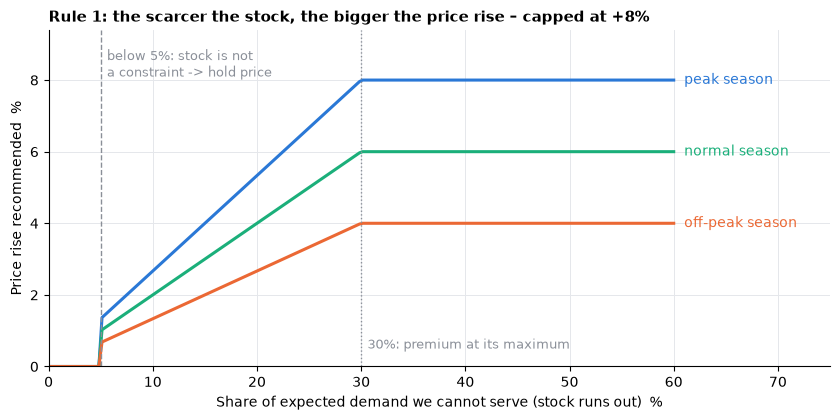

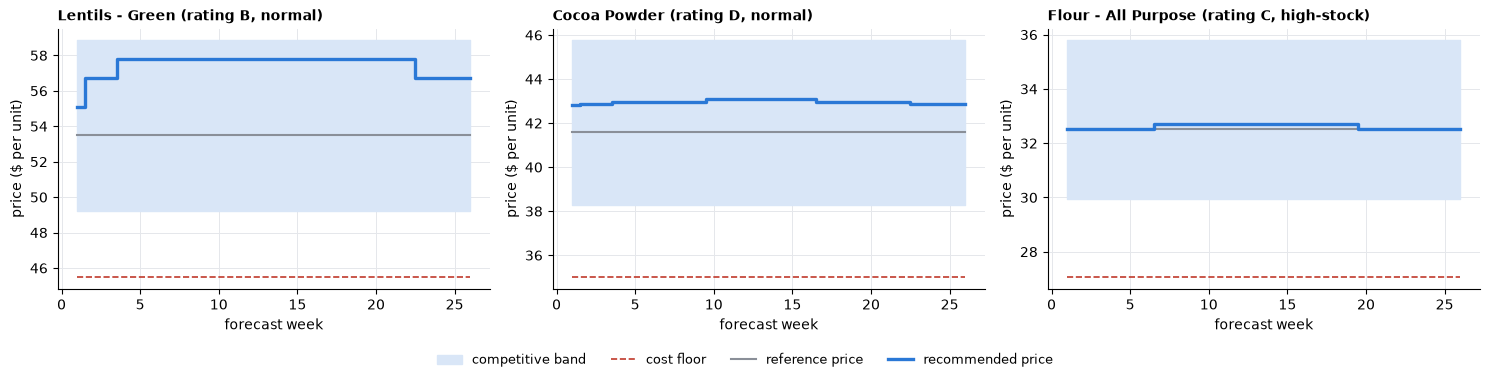

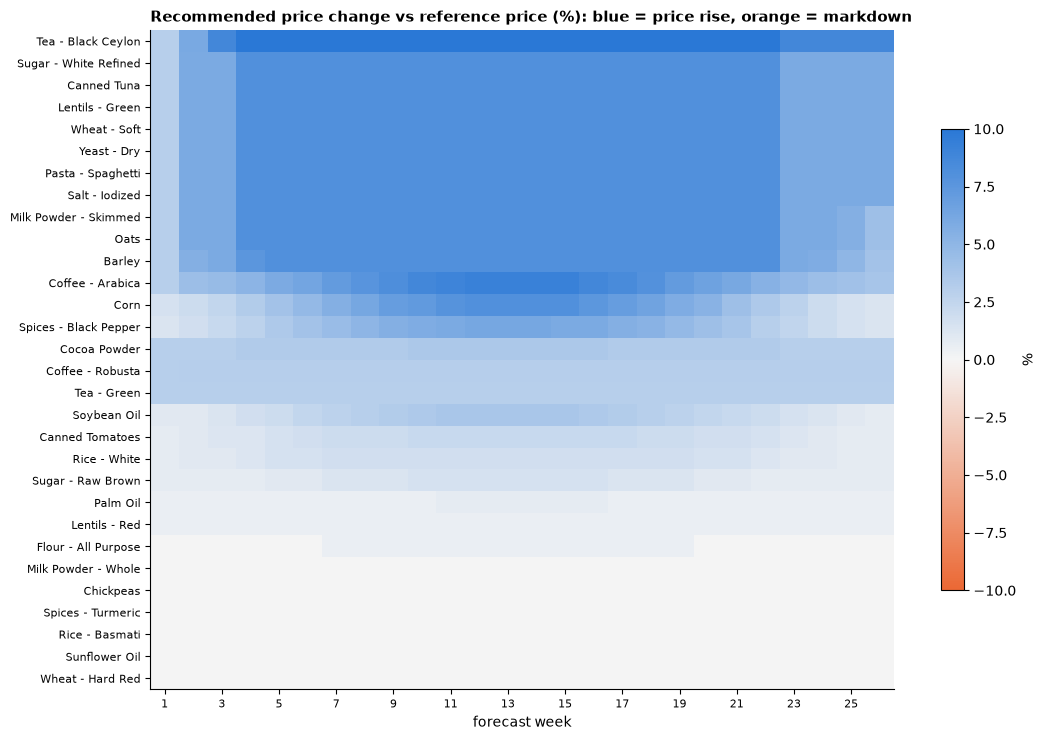

In [7]:
# ---- Figure 1: the rule as a picture - how big is the price rise, given how much demand we cannot serve? ------------------------
gaps = np.linspace(0, 0.6, 200)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for sf_, col in (("peak", BLUE), ("normal", GREEN), ("off-peak", ORANGE)):
    ax.plot(100 * gaps, [100 * scarcity_uplift(g_, sf_, P) for g_ in gaps], color=col, lw=2.2)
    ax.text(61, 100 * scarcity_uplift(0.6, sf_, P), f"{sf_} season", color=col, va="center", fontsize=10)
ax.axvline(100 * P["GAP_MIN"], color=GREY, ls="--", lw=1)
ax.text(100 * P["GAP_MIN"] + 0.6, 8.9, "below 5%: stock is not\na constraint -> hold price", color=GREY, fontsize=9, va="top")
ax.axvline(100 * P["G_FULL"], color=GREY, ls=":", lw=1)
ax.text(100 * P["G_FULL"] + 0.6, 0.5, "30%: premium at its maximum", color=GREY, fontsize=9)
ax.set_xlim(0, 75); ax.set_ylim(0, 9.4)
ax.set_xlabel("Share of expected demand we cannot serve (stock runs out)  %"); ax.set_ylabel("Price rise recommended  %")
ax.set_title("Rule 1: the scarcer the stock, the bigger the price rise – capped at +8%", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / f"fig1_scarcity_rule_{VERSION}.png", dpi=150); plt.show()

# ---- Figure 2: price paths of three representative products ----------------------------------------------------------------
plan["rev_pot"] = plan.d50 * plan.p0
pick = [plan[plan.state.eq("Scarce") & plan.rating.isin(["A", "B", "C"])].groupby("product_name").rev_pot.sum().idxmax(),
        plan[plan.rating.isin(["D", "E"])].groupby("product_name").rev_pot.sum().idxmax(),
        plan[plan.segment.eq("high_stock")].groupby("product_name").rev_pot.sum().idxmax()]
pick = list(dict.fromkeys(pick))
fig, axes = plt.subplots(1, len(pick), figsize=(5 * len(pick), 3.8), sharex=True)
axes = np.atleast_1d(axes)
for ax, nm in zip(axes, pick):
    g = plan[plan.product_name == nm].sort_values("h")
    ax.fill_between(g.h, g.band_lo, g.band_hi, color="#d9e6f7", label="competitive band")
    ax.plot(g.h, g.floor, color=RED, ls="--", lw=1.2, label="cost floor")
    ax.plot(g.h, g.p0, color=GREY, lw=1.5, label="reference price")
    ax.step(g.h, g.price, where="mid", color=BLUE, lw=2.4, label="recommended price")
    ax.set_title(f"{nm} (rating {g.rating.iloc[0]}, {g.segment.iloc[0].replace('_', '-')})", loc="left", fontsize=10, fontweight="bold")
    ax.set_xlabel("forecast week"); ax.set_ylabel("price ($ per unit)")
hnd, lab = axes[0].get_legend_handles_labels()
fig.legend(hnd, lab, loc="lower center", ncol=4, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.07, 1, 1)); fig.savefig(FIG / f"fig2_price_paths_{VERSION}.png", dpi=150); plt.show()

# ---- Figure 3: heat map of all 780 recommendations -------------------------------------------------------------------------
hm = plan.pivot(index="product_name", columns="h", values="adj_pct")
order = hm.mean(axis=1).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 7.5))
vmax = max(abs(np.nanmin(hm.values)), np.nanmax(hm.values), 1e-9)
from matplotlib.colors import LinearSegmentedColormap
im = ax.imshow(hm.loc[order].values, aspect="auto", cmap=LinearSegmentedColormap.from_list("div", [ORANGE, "#f5f5f5", BLUE]), vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8); ax.set_xticks(range(0, 26, 2)); ax.set_xticklabels(range(1, 27, 2), fontsize=8)
ax.grid(False); ax.set_xlabel("forecast week")
ax.set_title("Recommended price change vs reference price (%): blue = price rise, orange = markdown", loc="left", fontsize=11, fontweight="bold")
cb = fig.colorbar(im, ax=ax, shrink=0.7); cb.set_label("%")
fig.tight_layout(); fig.savefig(FIG / f"fig3_price_heatmap_{VERSION}.png", dpi=150); plt.show()

## 6. Does it behave sensibly across a full year? (replay on the last 52 weeks + rule matrix)
The 26-week forecast covers mostly peak and normal weeks, so it cannot show how the rules behave in **off-peak** weeks. To see a full seasonal cycle, we **replay the engine on the last 52 weeks of history**, as if we had been using it:

* two decisions, one at the end of week 208 (for weeks 209–234) and one at the end of week 234 (for weeks 235–260);
* **only information available at the time is used**: prices and stock of earlier weeks, and a simple forecast = *demand in the same week a year earlier* (a deliberately plain forecast, so the replay does not borrow the Part 2 model);
* the outcome is then judged on what **actually** happened – real stock and reconstructed demand.

Caution: demand in stock-limited weeks is itself a reconstruction (Part 2), so the replay is an estimate, not an audited result.

In [8]:
DEM = hist.pivot(index="week_id", columns="product_id", values="demand_est")
STK = hist.pivot(index="week_id", columns="product_id", values="stock_units")
seg_of = prods.segment


def replay_rows(T, H=26):
    """Planning inputs for weeks T+1..T+H using only data up to week T."""
    last = hist[(hist.week_id > T - 13) & (hist.week_id <= T)].groupby("product_id")[["unit_price", "unit_cogs"]].mean()
    wk = np.arange(T - 51, T + 1)
    ratio = pd.DataFrame(DEM.loc[wk].values / DEM.loc[wk - 52].values, columns=DEM.columns)      # how far "same week last year" was off, trailing year
    q = {s: np.nanquantile(ratio[seg_of[seg_of == s].index].values, [0.1, 0.9]) for s in ("high_stock", "normal")}
    recs = []
    for pid in DEM.columns:
        for wk_ in range(T + 1, T + H + 1):
            d50 = DEM.loc[wk_ - 52, pid]
            lo, hi = q[seg_of[pid]]
            recs.append((pid, prods.product_name[pid], seg_of[pid], prods.category[pid], wk_, wk_ - T, d50, d50 * lo, d50 * hi,
                         last.unit_price[pid], last.unit_cogs[pid], woy.loc[wk_]))
    rw = pd.DataFrame(recs, columns=["product_id", "product_name", "segment", "category", "week_id", "h", "d50", "d10", "d90", "p0", "cost", "woy"])
    rw["sf"] = season_flag(rw.woy)
    pools = {pid: hist[(hist.product_id == pid) & (hist.week_id > T - 104) & (hist.week_id <= T)].stock_units.dropna().values for pid in DEM.columns}
    meta = dict(origin=T, last_week_used_for_prices=int(T), last_week_used_for_stock=int(T), last_week_used_for_forecast=int(T + H - 52))
    return rw, pools, meta


def evaluate_replay(pl, eps_list):
    """Judge engine prices on what actually happened: real stock, reconstructed demand."""
    act = pd.DataFrame({"D": DEM.stack(), "S": STK.stack()}).rename_axis(["week_id", "product_id"]).reset_index()
    m = pl.merge(act, on=["product_id", "week_id"], how="left")
    assert m.D.notna().all() and m.S.notna().all()
    k = m.category.map(cat.ecl_rate)
    recs = []
    for e in eps_list:
        recs.append(pd.DataFrame({"product_id": m.product_id, "product": m.product_name, "category": m.category, "segment": m.segment, "week_id": m.week_id, "eps": e,
                                  "units0": np.minimum(m.D, m.S), "units1": np.minimum(m.D * (m.price / m.p0) ** e, m.S),
                                  "p0": m.p0, "p1": m.price, "cost": m.cost, "ecl_rate": k}))
    return add_money(pd.concat(recs, ignore_index=True))


replay_plans, replay_meta = [], []
for T in (208, 234):
    rw, pl_pools, meta = replay_rows(T)
    pl = plan_prices(rw, pl_pools, cat, P)
    pl["origin"] = T
    pl = pl.merge(rw[["product_id", "week_id", "h", "sf"]].rename(columns={"sf": "sf_check"}), on=["product_id", "week_id"])
    replay_plans.append(pl); replay_meta.append(meta)
replay = pd.concat(replay_plans, ignore_index=True)
replay["reason"] = replay.apply(reason_text, axis=1)
print(f"replay: {len(replay)} product-weeks (weeks {replay.week_id.min()}-{replay.week_id.max()})")
display(replay.groupby("state").agg(product_weeks=("price", "size"), avg_adj_pct=("adj_pct", "mean")).round(2))

replay: 1560 product-weeks (weeks 209-260)


,product_weeks,avg_adj_pct
state,,
Balanced,104,0.0
Scarce,1196,3.1
Surplus,260,-0.0


In [9]:
# ---- rule matrix: what the rules actually did, by product type x season (the table promised in 2.3) ------------------------
def matrix(pl):
    t = pl.copy()
    t["move"] = np.where(t.adj_pct > 0.5, "price up", np.where(t.adj_pct < -0.5, "markdown", "hold"))
    g = t.groupby(["segment", "sf"]).agg(product_weeks=("price", "size"), avg_change_pct=("adj_pct", "mean"),
                                        share_up=("move", lambda s: 100 * (s == "price up").mean()),
                                        share_hold=("move", lambda s: 100 * (s == "hold").mean()),
                                        share_markdown=("move", lambda s: 100 * (s == "markdown").mean())).reset_index()
    g["segment"] = g.segment.map({"normal": "Normal-stock products", "high_stock": "High-stock products"})
    return g.rename(columns={"segment": "product type", "sf": "season"})


mx_replay, mx_fc = matrix(replay), matrix(plan)
display(Markdown("**Replay of the last 52 weeks (full seasonal cycle)**")); display(mx_replay.round(1))
display(Markdown("**Next 26 weeks**")); display(mx_fc.round(1))
hs_rp = replay[replay.segment == "high_stock"]
display(Markdown(f"""
**Reading the matrix**
* **Normal-stock products** are scarce in most weeks and get a price rise in peak and normal weeks; in off-peak weeks the premium is half-sized ({mx_replay[(mx_replay['product type'] == 'Normal-stock products') & (mx_replay.season == 'off-peak')].avg_change_pct.iloc[0]:+.1f}% on average vs {mx_replay[(mx_replay['product type'] == 'Normal-stock products') & (mx_replay.season == 'peak')].avg_change_pct.iloc[0]:+.1f}% in peak weeks).
* **High-stock products**: the price is held in {100 * (hs_rp.adj_pct.abs() <= 0.5).mean():.0f}% of replay weeks. A markdown is considered in quiet weeks, but it is **rejected whenever it would not pay for itself** (break-even sensitivity: Section 10). The few price rises are weeks in which a product with moderate stock (Rice - Basmati, Flour) becomes scarce.
* Over the whole replay, {100 * (replay.adj_pct > 0.5).mean():.0f}% of product-weeks got a price rise, {100 * (replay.adj_pct < -0.5).mean():.0f}% a markdown, and the rest were held.
"""))

**Replay of the last 52 weeks (full seasonal cycle)**

,product type,season,product_weeks,avg_change_pct,share_up,share_hold,share_markdown
0,High-stock products,normal,98,0.0,0.0,100.0,0.0
1,High-stock products,off-peak,133,0.0,0.0,100.0,0.0
2,High-stock products,peak,133,-0.0,0.0,100.0,0.0
3,Normal-stock products,normal,322,2.8,94.1,5.9,0.0
4,Normal-stock products,off-peak,437,1.4,90.4,9.6,0.0
5,Normal-stock products,peak,437,5.0,97.0,3.0,0.0


**Next 26 weeks**

,product type,season,product_weeks,avg_change_pct,share_up,share_hold,share_markdown
0,High-stock products,normal,49,0.0,0.0,100.0,0.0
1,High-stock products,peak,133,0.0,9.8,90.2,0.0
2,Normal-stock products,normal,161,3.6,100.0,0.0,0.0
3,Normal-stock products,peak,437,5.5,100.0,0.0,0.0



**Reading the matrix**
* **Normal-stock products** are scarce in most weeks and get a price rise in peak and normal weeks; in off-peak weeks the premium is half-sized (+1.4% on average vs +5.0% in peak weeks).
* **High-stock products**: the price is held in 100% of replay weeks. A markdown is considered in quiet weeks, but it is **rejected whenever it would not pay for itself** (break-even sensitivity: Section 10). The few price rises are weeks in which a product with moderate stock (Rice - Basmati, Flour) becomes scarce.
* Over the whole replay, 72% of product-weeks got a price rise, 0% a markdown, and the rest were held.


## 7. Safety checks – do the prices really respect the rules?
Automatic tests on **both** price sets (the 26-week plan and the 52-week replay). A rule that is only written down is not a rule; these tests fail loudly if the engine ever breaks a limit.

In [10]:
checks = []


def check(name, passed, detail=""):
    checks.append({"check": name, "passed": bool(passed), "detail": str(detail)})


allp = pd.concat([plan.assign(price_set="forecast"), replay.assign(price_set="replay")], ignore_index=True)
tol = 0.0006                                                          # prices are rounded to 3 decimals
hand = dict(a=scarcity_uplift(0.30, "peak", P), b=scarcity_uplift(0.15, "normal", P), c=scarcity_uplift(0.04, "peak", P),
            d=markdown_depth(104, "off-peak", "A", P), e=markdown_depth(26, "off-peak", "A", P), f=markdown_depth(52, "off-peak", "A", P),
            g=markdown_depth(104, "peak", "A", P), h=markdown_depth(104, "off-peak", "D", P), i=markdown_depth(104, "off-peak", "C", P))

# --- structure -----------------------------------------------------------------------------------------------------------------
check("Plan is complete: 30 products x 26 weeks, no missing price", len(plan) == 780 and plan.price.notna().all() and plan.groupby("product_id").size().eq(26).all())
check("Replay is complete: 30 products x 52 weeks, no missing price", len(replay) == 1560 and replay.price.notna().all())
# --- hard guardrails (Rule 5) ----------------------------------------------------------------------------------------------------
check("Competitive band: every price within -8% ... +10% of the reference price",
      ((allp.price >= allp.p0 * (1 - P["BAND_DOWN"]) - tol) & (allp.price <= allp.p0 * (1 + P["BAND_UP"]) + tol)).all(),
      f"{len(allp)} prices; min {allp.adj_pct.min():+.2f}%, max {allp.adj_pct.max():+.2f}%")
check("Cost floor: every price above COGS + minimum markup + carrying cost + expected credit loss", (allp.price >= allp.floor - tol).all(),
      f"smallest margin over floor ${(allp.price - allp.floor).min():.3f}")
step = []
for _, g in allp.sort_values(["price_set", "product_id", "week_id"]).groupby(["price_set", "origin", "product_id"]):
    prev = np.r_[g.p0.iloc[0], g.price.values[:-1]]
    step.append(np.abs(g.price.values - prev) / prev)
step = np.concatenate(step)
check("Stability: no price moves more than 3% from the previous week", (step <= P["STEP_MAX"] + tol / allp.p0.min()).all(), f"largest weekly move {100 * step.max():.2f}%")
# --- credit rule (Rule 4) -----------------------------------------------------------------------------------------------------------
de = allp[allp.rating.isin(["D", "E"])]
c_ = allp[allp.rating == "C"]
check("Credit D/E: never below the reference price (no discounts)", (de.price >= de.p0 - tol).all(), f"{len(de)} price-weeks in D/E categories: {sorted(de.category.unique())}")
check("Credit C: markdown never deeper than 5%", ((c_.p0 - c_.price) / c_.p0 <= P["MD_CAP_C"] + tol / c_.p0.min()).all(), f"{len(c_)} price-weeks")
check("No markdown is ever applied in a peak-season week", (allp[allp.sf == "peak"].md_applied == 0).all())
# --- rule arithmetic against hand calculations ------------------------------------------------------------------------------------
check("Hand calc Rule 1: 30% unserved in peak -> +8.0%; 15% unserved in normal season -> +3.0%; 4% unserved -> 0%",
      np.isclose(hand["a"], 0.08) and np.isclose(hand["b"], 0.03) and hand["c"] == 0, f"{hand['a']:.3f} / {hand['b']:.3f} / {hand['c']:.3f}")
check("Hand calc Rule 3: 104 weeks cover off-peak -> -10%; 26 weeks -> 0; 52 weeks -> -5%; peak -> 0; rating D -> 0; rating C -> capped at -5%",
      np.isclose(hand["d"], 0.10) and hand["e"] == 0 and np.isclose(hand["f"], 0.05) and hand["g"] == 0 and hand["h"] == 0 and np.isclose(hand["i"], 0.05),
      " / ".join(f"{hand[k]:.3f}" for k in "defghi"))
mono = all(np.all(np.diff([scarcity_uplift(g_, s_, P) for g_ in np.linspace(0, 1, 101)]) >= -1e-12) for s_ in P["SEASON_MULT"])
check("Rule 1 is monotone: more unserved demand never lowers the premium (all seasons)", mono)
check("Rule 1 ordering: peak premium >= normal >= off-peak at the same scarcity", scarcity_uplift(0.2, "peak", P) >= scarcity_uplift(0.2, "normal", P) >= scarcity_uplift(0.2, "off-peak", P))
# --- behaviour ---------------------------------------------------------------------------------------------------------------------------
plan_again = plan_prices(rows_fc, pools_fc, cat, P)
check("Deterministic: re-running the engine gives identical prices", np.allclose(plan_again.price.values, plan.sort_values(["product_id", "week_id"]).price.values))
meta_ok = all(m["last_week_used_for_prices"] <= m["origin"] and m["last_week_used_for_stock"] <= m["origin"] and m["last_week_used_for_forecast"] <= m["origin"] for m in replay_meta)
check("Replay uses only information available at decision time (prices, stock and forecast inputs up to the origin week)", meta_ok, str(replay_meta))
tests = pd.DataFrame(checks)
display(tests)
assert tests.passed.all(), "a guardrail was broken - see the table"

,check,passed,detail
0,"Plan is complete: 30 products x 26 weeks, no m...",True,
1,"Replay is complete: 30 products x 52 weeks, no...",True,
2,Competitive band: every price within -8% ... +...,True,"2340 prices; min -0.01%, max +10.00%"
3,Cost floor: every price above COGS + minimum m...,True,smallest margin over floor $1.303
4,Stability: no price moves more than 3% from th...,True,largest weekly move 3.00%
5,Credit D/E: never below the reference price (n...,True,390 price-weeks in D/E categories: ['Beverages...
6,Credit C: markdown never deeper than 5%,True,1014 price-weeks
7,No markdown is ever applied in a peak-season week,True,
8,Hand calc Rule 1: 30% unserved in peak -> +8.0...,True,0.080 / 0.030 / 0.000
9,Hand calc Rule 3: 104 weeks cover off-peak -> ...,True,0.100 / 0.000 / 0.050 / 0.000 / 0.000 / 0.050


## 8. Expected money impact – shown as a range, not a single number
**What is compared:** the engine's prices versus *staying at today's reference price*, over the same 26 weeks, using the same simulated demand and stock.

**Why a range:** nobody knows how customers will react to the price changes. We therefore show the result for five possible reactions:

| Customer reaction (ε) | Meaning |
|---|---|
| **0** | customers do not react at all |
| **−0.5** | a 1% price rise loses 0.5% of demand |
| **−1.0** (*planning case*) | a 1% rise loses 1% of demand |
| **−2.0** | a 1% rise loses 2% of demand |
| **−3.0** | very price-sensitive customers |

**What "profit" means here:** gross profit minus the expected credit losses (default risk from the Part 3 assumptions). Revenue and units are shown too.

In [11]:
ev = evaluate_sim(plan, pools_fc, cat, P, EPS_SCENARIOS)
roi_fc = roi_table(ev)
roi_fc["scenario"] = roi_fc.eps.map({0.0: "customers ignore price", -0.5: "low sensitivity", -1.0: "planning case", -2.0: "high sensitivity", -3.0: "very high sensitivity"})

# part 2 consistency: simulated baseline vs the expected sales stored in the Part 2 forecast database
b0 = ev[ev.eps == 0].units0.sum(); b2 = plan.part2_expected_sales.sum()
# split: what comes from scarcity pricing and what from the credit risk premium
plan_nc = plan_prices(rows_fc, pools_fc, cat, {**P, "CREDIT_RULES": False})
ev_nc = evaluate_sim(plan_nc, pools_fc, cat, P, EPS_SCENARIOS)
roi_nc = roi_table(ev_nc)
roi_fc["d_net_profit_scarcity_only"] = roi_nc.d_net_profit.values
roi_fc["d_net_profit_credit_rule"] = roi_fc.d_net_profit - roi_fc.d_net_profit_scarcity_only
show = roi_fc[["scenario", "eps", "d_units_%", "d_revenue", "d_gross_profit", "d_net_profit", "d_net_profit_%", "d_net_profit_scarcity_only", "d_net_profit_credit_rule"]]
display(show.round(1))
BASE_NET, BASE_REV = ev[ev.eps == 0].net0.sum(), ev[ev.eps == 0].rev0.sum()
cent = roi_fc[roi_fc.eps == P["EPS_PLAN"]].iloc[0]
print(f"Baseline (hold today's price): revenue {money(BASE_REV)} · profit after credit losses {money(BASE_NET)} over 26 weeks")
print(f"Simulated baseline units vs Part 2 expected sales: {b0:,.0f} vs {b2:,.0f} ({100 * (b0 / b2 - 1):+.1f}%)")

,scenario,eps,d_units_%,d_revenue,d_gross_profit,d_net_profit,d_net_profit_%,d_net_profit_scarcity_only,d_net_profit_credit_rule
0,very high sensitivity,-3.0,-1.6,676012.8,1159591.2,1154884.9,15.5,1063621.2,91263.7
1,high sensitivity,-2.0,-0.9,935995.8,1223981.4,1216613.9,16.3,1100720.4,115893.5
2,planning case,-1.0,-0.4,1138413.1,1273117.9,1263583.5,17.0,1125373.1,138210.4
3,low sensitivity,-0.5,-0.2,1229274.3,1294995.8,1284473.9,17.2,1135713.3,148760.6
4,customers ignore price,0.0,0.0,1315745.9,1315745.9,1304279.6,17.5,1145272.1,159007.5


Baseline (hold today's price): revenue $35.8M · profit after credit losses $7.5M over 26 weeks
Simulated baseline units vs Part 2 expected sales: 1,092,607 vs 1,093,377 (-0.1%)


,product,category,segment,d_units_%,d_revenue,d_net_profit,d_net_profit_%
13,Oats,Cereals & Grains,normal,-0.1,148101.0,147894.6,35.3
9,Lentils - Green,Pulses,normal,-0.0,135130.7,134254.2,37.2
7,Corn,Cereals & Grains,normal,-0.3,94770.5,99512.1,22.5
28,Wheat - Soft,Cereals & Grains,normal,-0.0,89916.9,89360.3,32.1
25,Tea - Black Ceylon,Beverages & Cocoa,normal,-0.0,86264.5,85101.1,45.3
29,Yeast - Dry,Spices & Seasonings,normal,-0.0,82167.8,81308.8,34.7
5,Coffee - Arabica,Beverages & Cocoa,normal,-0.8,67351.5,73641.9,33.1
15,Pasta - Spaghetti,Cereals & Grains,normal,0.0,68786.9,68305.4,36.8
20,Spices - Black Pepper,Spices & Seasonings,normal,-0.4,61794.7,66415.3,18.1
4,Cocoa Powder,Beverages & Cocoa,normal,-1.9,23658.5,49810.4,13.9


,scenario,eps,d_units_%,d_revenue,d_net_profit,d_net_profit_%
0,very high sensitivity,-3.0,-1.6,428942.5,1266606.2,9.4
1,high sensitivity,-2.0,-1.0,808742.4,1351500.0,10.0
2,planning case,-1.0,-0.5,1168598.2,1431372.4,10.6
3,low sensitivity,-0.5,-0.3,1346080.3,1470710.4,10.9
4,customers ignore price,0.0,0.0,1524041.7,1510140.5,11.2


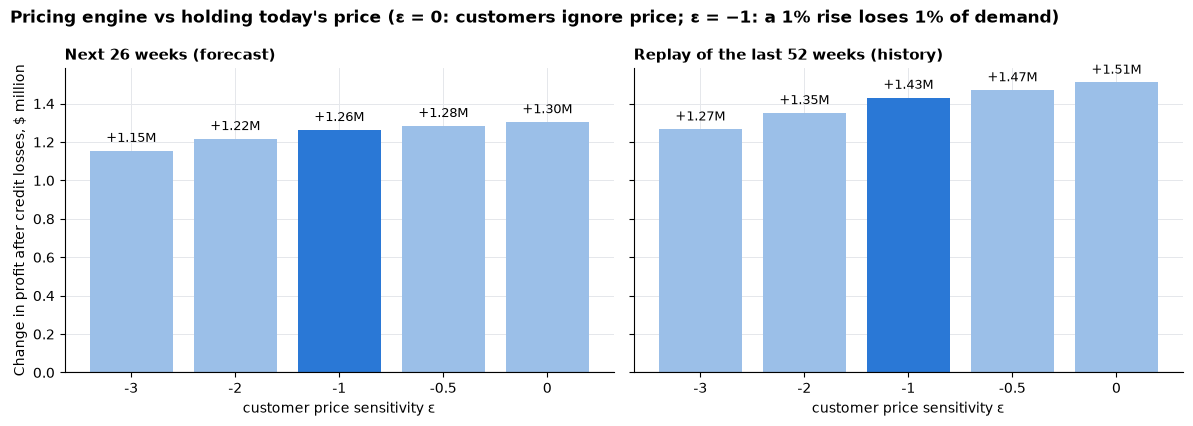

In [12]:
# ---- by product, central case ------------------------------------------------------------------------------------------------------
by_prod = roi_table(ev[ev.eps == P["EPS_PLAN"]], by=["product", "category", "segment"]).sort_values("d_net_profit", ascending=False)
display(by_prod[["product", "category", "segment", "d_units_%", "d_revenue", "d_net_profit", "d_net_profit_%"]].head(10).round(1))

# ---- replay: what the rules would have earned over the last 52 weeks -------------------------------------------------------------
ev_rp = evaluate_replay(replay, EPS_SCENARIOS)
roi_rp = roi_table(ev_rp)
roi_rp["scenario"] = roi_fc.scenario.values
display(roi_rp[["scenario", "eps", "d_units_%", "d_revenue", "d_net_profit", "d_net_profit_%"]].round(1))
rp_base = ev_rp[ev_rp.eps == 0].net0.sum()

# ---- Figure 4: money impact by customer reaction ------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, tab, ttl in ((axes[0], roi_fc, "Next 26 weeks (forecast)"), (axes[1], roi_rp, "Replay of the last 52 weeks (history)")):
    cols = [BLUE if e == P["EPS_PLAN"] else "#9bbfe8" for e in tab.eps]
    ax.bar(range(len(tab)), tab.d_net_profit / 1e6, color=cols)
    for i, v in enumerate(tab.d_net_profit / 1e6):
        ax.text(i, v + (0.03 if v >= 0 else -0.03), f"{v:+.2f}M", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.axhline(0, color="#444", lw=0.8)
    ax.set_xticks(range(len(tab))); ax.set_xticklabels([f"{e:g}" for e in tab.eps])
    ax.set_xlabel("customer price sensitivity ε")
    ax.set_title(ttl, loc="left", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Change in profit after credit losses, $ million")
fig.suptitle("Pricing engine vs holding today's price (ε = 0: customers ignore price; ε = −1: a 1% rise loses 1% of demand)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / f"fig4_money_impact_{VERSION}.png", dpi=150); plt.show()

In [13]:
# ---- economic checks (appended to the safety checks) -------------------------------------------------------------------------------
eco0 = len(checks)
check("Simulated baseline reproduces the Part 2 expected sales within 5%", abs(b0 / b2 - 1) < 0.05, f"{100 * (b0 / b2 - 1):+.2f}%")
check("Benefit falls as customers become more price-sensitive (monotone in ε)", roi_fc.sort_values("eps", ascending=False).d_net_profit.is_monotonic_decreasing)
check("If customers ignore price (ε = 0) the engine can only add profit", roi_fc[roi_fc.eps == 0].d_net_profit.iloc[0] > 0)
check("Sell-out protection: with scarcity-only pricing and stressed customers (ε = −2) expected units fall by at most 1% + 0.5 point",
      roi_nc[roi_nc.eps == P["EPS_STRESS"]]["d_units_%"].iloc[0] > -(100 * P["VOL_TOL"] + 0.5), f"{roi_nc[roi_nc.eps == P['EPS_STRESS']]['d_units_%'].iloc[0]:+.2f}%")
check("Reconciliation: money impact of the 780 rows equals the sum over products", np.isclose(by_prod.d_net_profit.sum(), cent.d_net_profit))
tests = pd.DataFrame(checks)
display(tests.iloc[eco0:])
print(f"All {len(tests)} checks passed: {tests.passed.all()}")
assert tests.passed.all()

,check,passed,detail
14,Simulated baseline reproduces the Part 2 expec...,True,-0.07%
15,Benefit falls as customers become more price-s...,True,
16,If customers ignore price (ε = 0) the engine c...,True,
17,Sell-out protection: with scarcity-only pricin...,True,-0.47%
18,Reconciliation: money impact of the 780 rows e...,True,


All 19 checks passed: True


## 9. How sensitive is the result to our own settings?
The rules contain choices (maximum premium, how fast prices may move, …). This section changes one setting at a time and shows how the 26-week profit gain moves, for each customer reaction. **A good rule set is not fragile**: small changes in settings should not flip the conclusion.

,setting,value,is_default,eps=0,eps=-0.5,eps=-1,eps=-2,eps=-3
0,U_MAX (largest premium),0.04,False,873686.0,854448.0,834547.0,792267.0,745643.0
1,U_MAX (largest premium),0.06,False,1107791.0,1088128.0,1067542.0,1022496.0,968706.0
2,U_MAX (largest premium),0.08,True,1304280.0,1284474.0,1263583.0,1216614.0,1154885.0
3,U_MAX (largest premium),0.10,False,1468652.0,1448803.0,1427764.0,1378931.0,1305425.0
4,G_FULL (scarcity at full premium),0.20,False,1304280.0,1284474.0,1263583.0,1216614.0,1154885.0
5,G_FULL (scarcity at full premium),0.30,True,1304280.0,1284474.0,1263583.0,1216614.0,1154885.0
6,G_FULL (scarcity at full premium),0.50,False,1301990.0,1282194.0,1261324.0,1214505.0,1153246.0
7,STEP_MAX (weekly step),0.02,False,1288694.0,1269075.0,1248387.0,1201977.0,1141184.0
8,STEP_MAX (weekly step),0.03,True,1304280.0,1284474.0,1263583.0,1216614.0,1154885.0
9,STEP_MAX (weekly step),0.05,False,1313407.0,1293565.0,1272621.0,1225435.0,1163249.0



**Reading the table (planning case, ε = −1).** Across 16 settings the 26-week profit gain stays **positive in every case** and ranges from **$635K** to **$1.6M** (default $1.3M).
The setting that matters most is **VOL_TOL (units we accept to lose)** (spread $1.0M): it decides how much volume risk we accept. The maximum premium and the weekly step matter less; the scarcity threshold hardly matters because most scarce weeks are far above it.


sensitivity runs took 6s


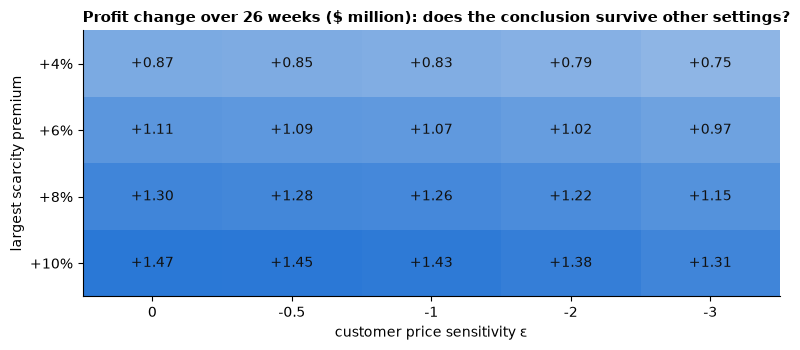

In [14]:
import time
t0 = time.time()


def variant(**kw):
    Pv = {**P, **kw}
    return roi_table(evaluate_sim(plan_prices(rows_fc, pools_fc, cat, Pv), pools_fc, cat, Pv, EPS_SCENARIOS)).set_index("eps").d_net_profit


grid = [("U_MAX (largest premium)", "U_MAX", [0.04, 0.06, 0.08, 0.10]),
        ("G_FULL (scarcity at full premium)", "G_FULL", [0.20, 0.30, 0.50]),
        ("STEP_MAX (weekly step)", "STEP_MAX", [0.02, 0.03, 0.05]),
        ("VOL_TOL (units we accept to lose)", "VOL_TOL", [0.0, 0.01, 0.03]),
        ("EPS_STRESS (protection strictness)", "EPS_STRESS", [-1.0, -2.0, -3.0])]
rows_s = []
for label, key, vals in grid:
    for v in vals:
        r_ = variant(**{key: v})
        rows_s.append({"setting": label, "value": v, "is_default": v == P[key], **{f"eps={e:g}": r_[e] for e in EPS_SCENARIOS}})
sens = pd.DataFrame(rows_s)
display(sens.round({c: 0 for c in sens.columns if c.startswith("eps=")}))
cen = sens[f"eps={P['EPS_PLAN']:g}"]
SENS_MIN, SENS_MAX = cen.min(), cen.max()
worst = sens.loc[cen.idxmin()]
spread = sens.groupby("setting")[f"eps={P['EPS_PLAN']:g}"].agg(lambda s: s.max() - s.min()).sort_values(ascending=False)
display(Markdown(f"""
**Reading the table (planning case, ε = −1).** Across {len(sens)} settings the 26-week profit gain stays **positive in every case** and ranges from **{money(SENS_MIN)}** to **{money(SENS_MAX)}** (default {money(cen[sens.is_default].iloc[0])}).
The setting that matters most is **{spread.index[0]}** (spread {money(spread.iloc[0])}): it decides how much volume risk we accept. The maximum premium and the weekly step matter less; the scarcity threshold hardly matters because most scarce weeks are far above it.
"""))
print(f"sensitivity runs took {time.time() - t0:.0f}s")

# ---- Figure 5: heat map premium cap x customer reaction ------------------------------------------------------------------------------
um = sens[sens.setting.str.startswith("U_MAX")]
M = um[[f"eps={e:g}" for e in EPS_SCENARIOS]].values / 1e6
fig, ax = plt.subplots(figsize=(8, 3.6))
from matplotlib.colors import LinearSegmentedColormap
im = ax.imshow(M, cmap=LinearSegmentedColormap.from_list("d", [ORANGE, "#f5f5f5", BLUE]), vmin=-np.abs(M).max(), vmax=np.abs(M).max(), aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels([f"{e:g}" for e in EPS_SCENARIOS]); ax.set_yticks(range(len(um))); ax.set_yticklabels([f"+{100 * v:.0f}%" for v in um.value])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:+.2f}", ha="center", va="center", fontsize=10, color="#111")
ax.grid(False); ax.set_xlabel("customer price sensitivity ε"); ax.set_ylabel("largest scarcity premium")
ax.set_title("Profit change over 26 weeks ($ million): does the conclusion survive other settings?", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / f"fig5_sensitivity_{VERSION}.png", dpi=150); plt.show()

### 9.2 The biggest risk: what if our demand estimate is too high?
Everything above rests on one belief: *demand is about twice the stock in most weeks*. That demand is **reconstructed** (sales are capped by stock, so true demand is never observed – Part 2). If the reconstruction overstates demand, the engine would raise prices in weeks that are not really scarce and lose units.
The test: keep the engine's prices (planned with our estimate) but judge them against a **lower true demand** – 80%, 60%, 50%, 40% of the estimate.

In [15]:
rows_h = []
for f in (1.0, 0.8, 0.6, 0.5, 0.4):
    pf = plan.assign(d50=plan.d50 * f, d10=plan.d10 * f, d90=plan.d90 * f)
    rt = roi_table(evaluate_sim(pf, pools_fc, cat, P, EPS_SCENARIOS)).set_index("eps")
    rows_h.append({"true demand vs estimate": f"{100 * f:.0f}%", "f": f, **{f"profit gain eps={e:g}": rt.loc[e, "d_net_profit"] for e in EPS_SCENARIOS},
                   "units change % (eps=-1)": rt.loc[-1.0, "d_units_%"], "units change % (eps=-2)": rt.loc[-2.0, "d_units_%"]})
haircut = pd.DataFrame(rows_h)
CK = f"profit gain eps={P['EPS_PLAN']:g}"
display(haircut.drop(columns="f").round({c: 0 for c in haircut.columns if c.startswith("profit")}).round(2))
h50 = haircut[haircut.f == 0.5].iloc[0]; h60 = haircut[haircut.f == 0.6].iloc[0]
neg = haircut[haircut[CK] <= 0]
display(Markdown(f"""
**Reading the table.** If true demand were only **60%** of our estimate, the planning-case gain would still be **{money(h60[CK])}** (units {h60['units change % (eps=-1)']:+.1f}%);
at **50%** it would be **{money(h50[CK])}** (units {h50['units change % (eps=-1)']:+.1f}%).
{"The gain turns negative when true demand falls to " + str(neg['true demand vs estimate'].iloc[0]) + " of the estimate." if len(neg) else "The gain stays positive in every case tested."}
The reason is the structure of the rules: prices are raised only where stock is far below demand, so demand has to fall a long way before a price rise starts costing units.
"""))

,true demand vs estimate,profit gain eps=0,profit gain eps=-0.5,profit gain eps=-1,profit gain eps=-2,profit gain eps=-3,units change % (eps=-1),units change % (eps=-2)
0,100%,1304280.0,1284474.0,1263583.0,1216614.0,1154885.0,-0.44,-0.95
1,80%,1252515.0,1207385.0,1155261.0,1028409.0,872702.0,-1.14,-2.66
2,60%,1104625.0,1021392.0,938689.0,775772.0,610863.0,-2.37,-4.70
3,50%,989527.0,904836.0,817978.0,635405.0,439125.0,-2.78,-5.74
4,40%,836541.0,738605.0,639382.0,442823.0,256002.0,-3.93,-7.84



**Reading the table.** If true demand were only **60%** of our estimate, the planning-case gain would still be **$939K** (units -2.4%);
at **50%** it would be **$818K** (units -2.8%).
The gain stays positive in every case tested.
The reason is the structure of the rules: prices are raised only where stock is far below demand, so demand has to fall a long way before a price rise starts costing units.


## 10. Beyond price: stock and credit actions
Price is not the right tool for every problem. Two situations in this business need **non-price actions**, and the framework says so explicitly.

### 10.1 Over-stocked products – a price cut cannot fix them
For each product with more than 26 weeks of stock we ask: *how far would the price have to fall to sell the excess within one year?* If the answer is "below cost", price is the wrong lever and purchasing must stop instead.

,product_name,category,cover_weeks,excess_units,excess_capital,carrying_cost_per_year,volume_multiple_needed,price_cut_needed_eps-1_%,price_cut_needed_eps-3_%,price_at_eps-1_vs_cost
product_id,,,,,,,,,,
28,Wheat - Hard Red,Cereals & Grains,369.4,172983.4,6530814.7,783697.8,7.6,-86.8,-49.1,-0.8
13,Milk Powder - Whole,Dairy,169.5,105231.5,1383372.8,166004.7,3.8,-73.4,-35.7,-0.7
22,Spices - Turmeric,Spices & Seasonings,372.5,181309.9,1282767.7,153932.1,7.7,-87.0,-49.3,-0.8
25,Sunflower Oil,Oils & Fats,227.7,138359.3,1052222.5,126266.7,4.9,-79.5,-41.0,-0.7
4,Chickpeas,Pulses,64.4,35977.4,522823.4,62738.8,1.7,-42.5,-16.8,-0.3



**5 products hold more than 26 weeks of stock.** Together the excess ties up **$10.8M** (at cost) and costs about **$1.3M per year** to carry (at 12% a year).
To sell the excess *within one year by price alone*, demand would need to rise by a factor of 1.7–7.7; even if customers were very price-sensitive (ε = −3) that needs price cuts of
**17% to 49%** – deeper than the 10% maximum markdown. At ε = −1 the price needed would be **below cost for 5 of the 5 products**.
**Recommended actions instead:** stop purchasing until cover is below 26 weeks; offer bulk or export deals on the excess; review shelf-life risk of the slowest movers (Spices - Turmeric, Wheat - Hard Red, Sunflower Oil).


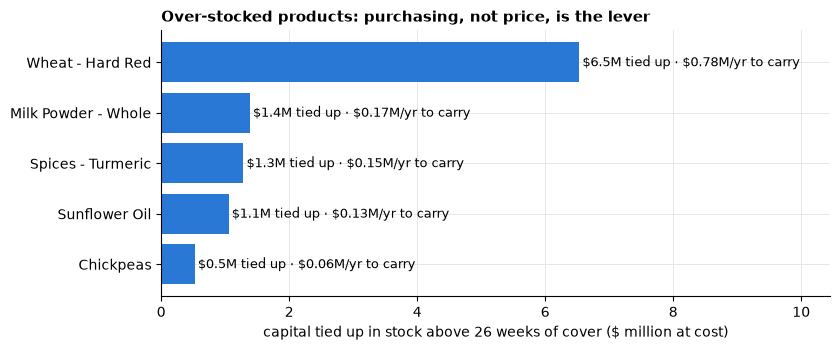

In [16]:
l13 = hist[hist.week_id > LAST - 13].groupby("product_id").agg(stock=("stock_units", "mean"), demand=("demand_est", "mean"))
pc = rows_fc.groupby("product_id")[["p0", "cost"]].first()
osd = l13.join(pc).join(prods[["product_name", "category", "segment"]])
osd["cover_weeks"] = osd.stock / osd.demand
osd["excess_units"] = (osd.stock - P["COVER_MAX"] * osd.demand).clip(lower=0)
osd["excess_capital"] = osd.excess_units * osd.cost
osd["carrying_cost_per_year"] = osd.excess_capital * P["CARRY_ANNUAL"]
osd["volume_multiple_needed"] = 1 + osd.excess_units / (52 * osd.demand)                     # to sell the excess within one year on top of normal sales
for e in (-1.0, -3.0):
    osd[f"price_cut_needed_eps{e:g}_%"] = 100 * (osd.volume_multiple_needed ** (1 / e) - 1)
osd["price_at_eps-1_vs_cost"] = osd.p0 * osd.volume_multiple_needed ** (1 / -1.0) / osd.cost - 1
over = osd[osd.cover_weeks > P["COVER_MAX"]].sort_values("excess_capital", ascending=False)
display(over[["product_name", "category", "cover_weeks", "excess_units", "excess_capital", "carrying_cost_per_year", "volume_multiple_needed",
              "price_cut_needed_eps-1_%", "price_cut_needed_eps-3_%", "price_at_eps-1_vs_cost"]].round(1))
EXCESS_CAP, EXCESS_CARRY = over.excess_capital.sum(), over.carrying_cost_per_year.sum()
display(Markdown(f"""
**{len(over)} products hold more than 26 weeks of stock.** Together the excess ties up **{money(EXCESS_CAP)}** (at cost) and costs about **{money(EXCESS_CARRY)} per year** to carry (at {100 * P['CARRY_ANNUAL']:.0f}% a year).
To sell the excess *within one year by price alone*, demand would need to rise by a factor of {over.volume_multiple_needed.min():.1f}–{over.volume_multiple_needed.max():.1f}; even if customers were very price-sensitive (ε = −3) that needs price cuts of
**{abs(over['price_cut_needed_eps-3_%']).min():.0f}% to {abs(over['price_cut_needed_eps-3_%']).max():.0f}%** – deeper than the 10% maximum markdown. At ε = −1 the price needed would be **below cost for {int((over['price_at_eps-1_vs_cost'] < 0).sum())} of the {len(over)} products**.
**Recommended actions instead:** stop purchasing until cover is below 26 weeks; offer bulk or export deals on the excess; review shelf-life risk of the slowest movers ({', '.join(over.sort_values('cover_weeks', ascending=False).product_name.head(3))}).
"""))
fig, ax = plt.subplots(figsize=(8.5, 3.6))
o = over.sort_values("excess_capital")
ax.barh(o.product_name, o.excess_capital / 1e6, color=BLUE)
for i, (v, c) in enumerate(zip(o.excess_capital / 1e6, o.carrying_cost_per_year / 1e6)):
    ax.text(v + 0.05, i, f"\\${v:.1f}M tied up · \\${c:.2f}M/yr to carry", va="center", fontsize=9)
ax.set_xlim(0, o.excess_capital.max() / 1e6 * 1.6); ax.set_xlabel("capital tied up in stock above 26 weeks of cover ($ million at cost)")
ax.set_title("Over-stocked products: purchasing, not price, is the lever", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / f"fig6_overstock_{VERSION}.png", dpi=150); plt.show()

### 10.2 Credit-risk categories (rating D/E): price premium + shorter payment terms
Rule 4 asks high-risk categories to pay for the risk. The table shows, per category, the rating (assumption-based, Part 3), the risk premium and what a **15-day shorter payment term** would do to receivables (cash tied up in unpaid invoices).

In [17]:
cr = cat.copy()
cr["new_dso"] = cr.credit_share_pct / 100 * (cr.new_terms_days + cr.avg_delay_days)
cr["receivables_now"] = cr.revenue / 364 * cr.dso
cr["receivables_new"] = cr.revenue / 364 * cr.new_dso
cr["cash_freed"] = cr.receivables_now - cr.receivables_new
cr["funding_saving_per_year"] = cr.cash_freed * P["FUND_RATE"]
cr = cr.reset_index().rename(columns={"index": "category"})
credit_rules = cr[["category", "rating", "risk_score", "terms_days", "new_terms_days", "dso", "new_dso", "ecl_rate", "funding_rate", "risk_premium",
                   "revenue", "receivables_now", "cash_freed", "funding_saving_per_year"]].sort_values("risk_score", ascending=False)
display(credit_rules.round(3))
de_ = credit_rules[credit_rules.rating.isin(["D", "E"])]
if len(de_):
    display(Markdown(f"""
**{', '.join(de_.category)}** {'is' if len(de_) == 1 else 'are'} rated D/E (assumption-based): **no discounts**, a price premium of **{100 * de_.risk_premium.min():.1f}%** (expected credit loss {100 * de_.ecl_rate.min():.2f}% + funding cost {100 * de_.funding_rate.min():.2f}%),
and a recommended terms cut of {P['TERMS_CUT_DAYS']} days, which would free about **{money(de_.cash_freed.sum())}** of cash tied up in receivables (worth {money(de_.funding_saving_per_year.sum())} a year at {100 * P['FUND_RATE']:.0f}%).
"""))

,category,rating,risk_score,terms_days,new_terms_days,dso,new_dso,ecl_rate,funding_rate,risk_premium,revenue,receivables_now,cash_freed,funding_saving_per_year
0,Beverages & Cocoa,D,53.207,60,45,54.00,42.75,0.014,0.012,0.025,11671992.79,1731559.370,360741.535,28859.323
6,Spices & Seasonings,C,40.911,60,60,49.00,49.00,0.010,0.011,0.000,6697522.96,901589.629,0.000,0.000
2,Cereals & Grains,C,39.077,45,45,35.70,35.70,0.007,0.008,0.000,21870551.37,2144996.384,0.000,0.000
5,Pulses,B,32.715,45,45,33.15,33.15,0.007,0.007,0.000,9767333.75,889525.038,0.000,0.000
1,Canned Foods,B,28.930,45,45,33.80,33.80,0.007,0.007,0.000,2664694.43,247435.911,0.000,0.000
4,Oils & Fats,B,27.332,30,30,20.40,20.40,0.005,0.004,0.000,8266672.87,463297.051,0.000,0.000
7,Sugar,B,24.925,30,30,21.00,21.00,0.005,0.005,0.000,2332869.93,134588.650,0.000,0.000
3,Dairy,B,21.355,30,30,18.70,18.70,0.004,0.004,0.000,2081467.34,106932.525,0.000,0.000



**Beverages & Cocoa** is rated D/E (assumption-based): **no discounts**, a price premium of **2.5%** (expected credit loss 1.35% + funding cost 1.18%),
and a recommended terms cut of 15 days, which would free about **$361K** of cash tied up in receivables (worth $29K a year at 8%).


## 11. Pilot plan – replace assumptions with measurements
The engine is safe by design, but two things are still assumptions: *how customers react to price* and *what competitors charge*. A small, controlled pilot measures the first before a company-wide roll-out.

There is a catch that shapes the design: **for products that sell out, units sold equal stock, not demand** – so a price test on them cannot reveal demand, only whether we **still sell out** (which is exactly what the scarcity premium relies on). To learn real price sensitivity we need products where stock is ample.

* **Pilot A – "do we still sell out?"** (scarce products): raise prices by +3% or +5%, compare with matched control products. *Success:* units sold unchanged and stock still sells out.
* **Pilot B – "how sensitive are customers?"** (high-stock products, where demand is visible): alternate the price ±3% around the reference in random weeks, and measure units.

In [18]:
sc_share = plan.groupby("product_id").agg(scarce_share=("state", lambda s: (s == "Scarce").mean()), avg_change=("adj_pct", "mean"), rev=("rev_pot", "sum"))
cand = by_prod.merge(prods.reset_index()[["product_id", "product_name"]], left_on="product", right_on="product_name").merge(sc_share, left_on="product_id", right_index=True)
cand = cand[(cand.segment == "normal") & (cand.scarce_share >= 0.5)].sort_values("d_net_profit", ascending=False)
treat = cand.head(6).copy()
treat["price_test"] = ["+3%", "+5%"] * 3
rest = cand.iloc[6:]
ctrl = []
for r in treat.itertuples():
    pool_ = rest[~rest["product"].isin(ctrl)]
    same = pool_[pool_.category == r.category]
    pool_ = same if len(same) else pool_
    ctrl.append(pool_.iloc[(pool_.rev - r.rev).abs().argmin()]["product"])
treat["matched_control_product"] = ctrl
pilot_a = treat[["product", "category", "price_test", "matched_control_product", "scarce_share", "d_net_profit"]].rename(columns={"scarce_share": "share_of_weeks_scarce", "d_net_profit": "expected_gain_26wk_planning_case"})
pilot_a["duration_weeks"] = 8
pilot_a["success_criterion"] = "units sold within 1% of the control product and stock still sells out"
display(pilot_a.round(2))

hs = prods[prods.segment == "high_stock"].join(osd[["cover_weeks"]]).reset_index()[["product_name", "category", "cover_weeks"]].sort_values("cover_weeks", ascending=False)
display(Markdown("**Pilot B candidates (high-stock products, stock never limits sales):**")); display(hs.round(0))
sig = float(sigma_w["high_stock"])
swing = np.log(1.03 / 0.97)
mde = pd.DataFrame({f"{n} weeks per price level": [2.8 * sig * np.sqrt(2 / n) / np.sqrt(k) / swing for k in (3, 5, 7)] for n in (4, 6, 8, 12)},
                   index=[f"{k} products" for k in (3, 5, 7)]).round(2)
mde.index.name = "smallest price sensitivity |ε| we could detect"
display(mde)
display(Markdown(f"""
**Reading the table:** weekly demand of high-stock products is noisy by about **{100 * sig:.1f}%** even after removing season and trend. With **5 products and 6 weeks at each price level** a pilot can detect a price sensitivity of about
**|ε| ≥ {mde.iloc[1, 1]:.1f}**; more products or more weeks give a sharper answer. A cheaper first step is Pilot A, which only needs to confirm that stock still sells out.
"""))
pilot_b = hs.assign(price_levels="reference +3% / −3% in random weeks", duration_weeks=8, metric="units sold per week", decision_rule="estimate ε; update EPS_PLAN and EPS_STRESS")

,product,category,price_test,matched_control_product,share_of_weeks_scarce,expected_gain_26wk_planning_case,duration_weeks,success_criterion
0,Oats,Cereals & Grains,+3%,Rice - White,1.0,147894.64,8,units sold within 1% of the control product an...
1,Lentils - Green,Pulses,+5%,Lentils - Red,1.0,134254.17,8,units sold within 1% of the control product an...
2,Corn,Cereals & Grains,+3%,Pasta - Spaghetti,1.0,99512.07,8,units sold within 1% of the control product an...
3,Wheat - Soft,Cereals & Grains,+5%,Barley,1.0,89360.29,8,units sold within 1% of the control product an...
4,Tea - Black Ceylon,Beverages & Cocoa,+3%,Coffee - Arabica,1.0,85101.08,8,units sold within 1% of the control product an...
5,Yeast - Dry,Spices & Seasonings,+5%,Spices - Black Pepper,1.0,81308.79,8,units sold within 1% of the control product an...


**Pilot B candidates (high-stock products, stock never limits sales):**

,product_name,category,cover_weeks
4,Spices - Turmeric,Spices & Seasonings,373.0
6,Wheat - Hard Red,Cereals & Grains,369.0
5,Sunflower Oil,Oils & Fats,228.0
2,Milk Powder - Whole,Dairy,169.0
0,Chickpeas,Pulses,64.0
3,Rice - Basmati,Cereals & Grains,10.0
1,Flour - All Purpose,Cereals & Grains,6.0


,4 weeks per price level,6 weeks per price level,8 weeks per price level,12 weeks per price level
smallest price sensitivity |ε| we could detect,,,,
3 products,1.54,1.26,1.09,0.89
5 products,1.20,0.98,0.85,0.69
7 products,1.01,0.83,0.72,0.58



**Reading the table:** weekly demand of high-stock products is noisy by about **8.1%** even after removing season and trend. With **5 products and 6 weeks at each price level** a pilot can detect a price sensitivity of about
**|ε| ≥ 1.0**; more products or more weeks give a sharper answer. A cheaper first step is Pilot A, which only needs to confirm that stock still sells out.


## 12. Key numbers – the one-page summary

In [19]:
n_sc, n_ba, n_su = [int((plan.state == s).sum()) for s in ("Scarce", "Balanced", "Surplus")]
scarce = plan[plan.state == "Scarce"]
eps_lo_roi, eps_hi_roi = roi_fc[roi_fc.eps == -3.0].iloc[0], roi_fc[roi_fc.eps == 0.0].iloc[0]
cent_rp = roi_rp[roi_rp.eps == P["EPS_PLAN"]].iloc[0]
md_cnt = int((plan.md_applied > 0).sum()) + int((replay.md_applied > 0).sum())
md_rej = int(plan.limits.str.contains("markdown rejected").sum()) + int(replay.limits.str.contains("markdown rejected").sum())
be_vals = pd.concat([plan.eps_breakeven, replay.eps_breakeven]).dropna()
KEY = f"""
**What the engine recommends for the next 26 weeks (30 products × 26 weeks = {len(plan)} prices)**
* **{100 * n_sc / len(plan):.0f}%** of product-weeks are **scarce** (price rise recommended, on average **{scarce.adj_pct.mean():+.1f}%** and never more than **{plan.adj_pct.max():+.1f}%**),
  **{100 * n_ba / len(plan):.0f}%** are balanced and **{100 * n_su / len(plan):.0f}%** surplus (price held).
* Markdowns: **{int((plan.md_applied > 0).sum())}** in the plan and **{int((replay.md_applied > 0).sum())}** in the 52-week replay. The engine **rejected {md_rej}** candidate markdowns because they would not pay for themselves
  (they would pay only if customers were about **{abs(be_vals.median()) if len(be_vals) else float('nan'):.1f}×** price-sensitive – far above anything this data supports).

**Money (profit after expected credit losses, versus holding today's prices)**
* **Planning case (ε = −1):** {money(cent.d_net_profit)} over 26 weeks (**{cent['d_net_profit_%']:+.1f}%** of {money(BASE_NET)}), with {cent['d_units_%']:+.2f}% units.
* **Range:** from **{money(eps_lo_roi.d_net_profit)}** (very price-sensitive customers, ε = −3) to **{money(eps_hi_roi.d_net_profit)}** (customers ignore price).
* **Replay of the last 52 weeks:** {money(cent_rp.d_net_profit)} in the planning case ({cent_rp['d_net_profit_%']:+.1f}% of {money(rp_base)}).
* Of the planning-case gain, **{money(cent.d_net_profit_scarcity_only)}** comes from scarcity pricing and **{money(cent.d_net_profit_credit_rule)}** from the credit-risk rule.

**Where price is *not* the answer**
* **{len(over)} products** hold over 26 weeks of stock: **{money(EXCESS_CAP)}** tied up, about **{money(EXCESS_CARRY)} a year** to carry – larger than the pricing gain. Stop buying; do not discount.
* Rating D/E categories ({', '.join(de_.category) if len(de_) else 'none'}): no discounts, {100 * de_.risk_premium.min() if len(de_) else 0:.1f}% risk premium, shorter terms (frees about {money(de_.cash_freed.sum()) if len(de_) else '$0'} of cash).

**Biggest risk – demand reconstruction:** if true demand were only 60% of our estimate the planning-case gain would still be {money(h60[CK])}; at 50% it would be {money(h50[CK])}.

**Safety:** all **{len(tests)} automatic checks passed** – band, cost floor, weekly step, credit rules, hand-calculated rule arithmetic, replay without look-ahead.

**What we do not know:** customer price sensitivity (data says {elasticity.iloc[0].coefficient:+.3f}, 95% range {eps_lo:+.2f} … {eps_hi:+.2f}), competitor prices, real credit data. **Next step:** run Pilots A and B (Section 11), then update the two sensitivity assumptions.
"""
display(Markdown(KEY))


**What the engine recommends for the next 26 weeks (30 products × 26 weeks = 780 prices)**
* **78%** of product-weeks are **scarce** (price rise recommended, on average **+4.9%** and never more than **+10.0%**),
  **5%** are balanced and **17%** surplus (price held).
* Markdowns: **0** in the plan and **0** in the 52-week replay. The engine **rejected 200** candidate markdowns because they would not pay for themselves
  (they would pay only if customers were about **3.8×** price-sensitive – far above anything this data supports).

**Money (profit after expected credit losses, versus holding today's prices)**
* **Planning case (ε = −1):** $1.3M over 26 weeks (**+17.0%** of $7.5M), with -0.44% units.
* **Range:** from **$1.2M** (very price-sensitive customers, ε = −3) to **$1.3M** (customers ignore price).
* **Replay of the last 52 weeks:** $1.4M in the planning case (+10.6% of $13.5M).
* Of the planning-case gain, **$1.1M** comes from scarcity pricing and **$138K** from the credit-risk rule.

**Where price is *not* the answer**
* **5 products** hold over 26 weeks of stock: **$10.8M** tied up, about **$1.3M a year** to carry – larger than the pricing gain. Stop buying; do not discount.
* Rating D/E categories (Beverages & Cocoa): no discounts, 2.5% risk premium, shorter terms (frees about $361K of cash).

**Biggest risk – demand reconstruction:** if true demand were only 60% of our estimate the planning-case gain would still be $939K; at 50% it would be $818K.

**Safety:** all **19 automatic checks passed** – band, cost floor, weekly step, credit rules, hand-calculated rule arithmetic, replay without look-ahead.

**What we do not know:** customer price sensitivity (data says -0.017, 95% range -0.06 … +0.02), competitor prices, real credit data. **Next step:** run Pilots A and B (Section 11), then update the two sensitivity assumptions.


## 13. Export everything to one Excel file (and a small database of the plan)
`part4_pricing_v1.0/pricing_results_v1.0.xlsx` – first sheet **Summary**, then the plain-language guide, the rulebook, parameters, the 780-row price plan (long and wide), the replay, money impact, sensitivity, safety checks, stock and credit actions, the pilot design and figures.
`pricing_plan_v1.0.db` holds the same plan in SQLite so a later dashboard version can read it.

In [20]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter


def plan_view(pl):
    t = pl.copy()
    t["service_gap_%"] = 100 * t.gap
    t["scarcity_premium_allowed_%"] = 100 * (t.m_protected - 1)
    t["credit_risk_premium_%"] = 100 * t.risk_premium
    t["markdown_applied_%"] = 100 * t.md_applied
    return t.rename(columns={"product_name": "product", "sf": "season", "p0": "reference_price", "price": "recommended_price", "adj_pct": "change_vs_reference_%",
                             "d50": "expected_demand_units", "d10": "demand_P10", "d90": "demand_P90", "cover": "weeks_of_stock_cover", "floor": "cost_floor",
                             "band_lo": "band_low", "band_hi": "band_high", "limits": "limits_that_applied", "reason": "reason_plain_language"})


COLS = ["product", "category", "rating", "week_id", "week_start", "h", "season", "state", "reference_price", "recommended_price", "change_vs_reference_%",
        "expected_demand_units", "demand_P10", "demand_P90", "service_gap_%", "weeks_of_stock_cover", "scarcity_premium_allowed_%", "credit_risk_premium_%",
        "markdown_applied_%", "cost_floor", "band_low", "band_high", "limits_that_applied", "reason_plain_language"]
plan_x = plan_view(plan)[COLS]
replay_x = plan_view(replay).assign(week_start="")[[c for c in COLS if c != "week_start"] + ["origin"]]
wide_price = plan.pivot(index="product_name", columns="h", values="price").add_prefix("wk")
wide_chg = plan.pivot(index="product_name", columns="h", values="adj_pct").add_prefix("wk").round(2)
by_product = plan.groupby(["product_name", "category", "segment", "rating"]).agg(
    reference_price=("p0", "first"), avg_recommended_price=("price", "mean"), avg_change_pct=("adj_pct", "mean"), max_change_pct=("adj_pct", "max"), min_change_pct=("adj_pct", "min"),
    weeks_scarce=("state", lambda s: int((s == "Scarce").sum())), weeks_balanced=("state", lambda s: int((s == "Balanced").sum())), weeks_surplus=("state", lambda s: int((s == "Surplus").sum()))).reset_index()
by_product = by_product.merge(by_prod[["product", "d_units_%", "d_revenue", "d_net_profit"]].rename(columns={"product": "product_name", "d_units_%": "planning_case_units_%", "d_revenue": "planning_case_revenue_gain", "d_net_profit": "planning_case_profit_gain"}), on="product_name")

rulebook = pd.DataFrame([
    ("Rule 1", "Scarcity premium", "The more of the expected demand we cannot serve, the more we charge; peak season uses the full premium, quiet seasons less.",
     "w = min(1, g/0.30) if g > 5% else 0;  u = 8% x w x m(season);  m = 1.00 / 0.75 / 0.50 (peak / normal / off-peak)", "U_MAX, GAP_MIN, G_FULL, SEASON_MULT"),
    ("Rule 2", "Sell-out protection", "Raise the price only as far as we would still sell (almost) the same units even if customers were twice as price-sensitive as assumed.",
     "largest M <= 1+u with E[min(D*M^-2, S)] >= 99% of E[min(D, S)]  (1,000 simulated demand/stock pairs)", "EPS_STRESS, VOL_TOL, SIM_N"),
    ("Rule 3", "Surplus & clearance", "Markdown only for products with more than 26 weeks of stock and no scarcity; deeper with more excess, only in quiet weeks, and only if it pays for itself.",
     "cover = S/D;  d = 10% x min(1, ln(cover/26)/ln(4)) x lull(season);  apply if Profit(P0(1-d); eps=-1) > Profit(P0; eps=-1)", "D_MAX, COVER_MAX, COVER_FULL, LULL, EPS_PLAN, CARRY_ANNUAL"),
    ("Rule 4", "Credit-risk rule", "A/B unchanged; C markdown at most 5%; D/E no markdowns, a risk premium and shorter payment terms.",
     "premium = share_on_credit x default_rate + DSO/365 x 8%;  target x (1 + premium)", "MD_CAP_C, FUND_RATE, TERMS_CUT_DAYS"),
    ("Rule 5", "Guardrails", "Price never below cost + minimum markup + carrying cost + expected credit loss; inside the competitive band; moves at most 3% per week.",
     "floor = COGS(1+5%+12%*4/52)/(1-ecl);  0.92 P0 <= price <= 1.10 P0;  |price_t / price_(t-1) - 1| <= 3%", "MIN_MARKUP, CARRY_ANNUAL, BAND_UP, BAND_DOWN, STEP_MAX"),
    ("Rule 6", "Final price", "Combine the rules, then apply the guardrails in order.",
     "target = P0 (1+u_protected)(1+premium)(1-d) -> floor -> band -> weekly step", ""),
], columns=["rule", "name", "in plain words", "math", "parameters"])

glossary = pd.DataFrame([
    ("Reference price (P0)", "Today's price: the average selling price of the last 13 weeks."),
    ("Expected demand (D)", "Units customers would buy in a week, from the Part 2 forecast, with a low case (P10) and a high case (P90)."),
    ("Service gap", "Share of expected demand we cannot serve because stock runs out. 0% = stock covers demand; 50% = half of the demand goes unserved."),
    ("Scarce / Balanced / Surplus", "Scarce: part of the demand cannot be served. Balanced: stock covers demand. Surplus: more than 26 weeks of stock."),
    ("Weeks of cover", "How many weeks the stock lasts at the expected weekly demand."),
    ("Peak / off-peak season", "Weeks in which the shared seasonal pattern is at least 10% above (peak) or below (off-peak) its yearly average."),
    ("Price sensitivity (elasticity, e)", "How much demand falls when the price rises by 1%. e = -1: a 1% rise loses 1% of demand. Not measurable from this data."),
    ("Sell-out protection", "The check that a price rise does not cost units: we still sell out even if customers are twice as price-sensitive as we assume."),
    ("Cost floor", "The lowest price allowed: cost + minimum markup + carrying cost + expected credit loss."),
    ("Competitive band", "How far the price may move from the reference price (-8% ... +10%). Stands in for competitor prices, which we do not have."),
    ("Credit rating A-E", "Risk class of a product category from the Part 3 credit layer; based on assumptions, not on customer data."),
    ("Profit after credit losses", "Gross profit minus the expected loss from customers who do not pay."),
    ("Replay", "Running the rules on the last 52 weeks as if they had been used, with only the information available at the time."),
], columns=["term", "plain-language meaning"])

assumptions = pd.DataFrame([
    ("A1", "Price sensitivity", "Unknown. Planning case -1, stress case -2, results shown for 0 ... -3. A pilot should replace this."),
    ("A2", "Competitor prices", "Not in the data. The 13-week average price +/- the band is the proxy for the market."),
    ("A3", "Credit layer", "Ratings, DSO and default rates come from the Part 3 assumptions (not customer data)."),
    ("A4", "Future stock", "Unknown. Simulated from each product's own last 104 weeks of stock (the same approach as Part 2)."),
    ("A5", "Demand", "Part 2 forecast with a lognormal spread read from its P10-P90 band; replay uses reconstructed demand, which is an estimate in stock-limited weeks."),
    ("A6", "Cost", "Unit cost held at its last-13-week average; no cost changes assumed."),
    ("A7", "Carrying cost and funding", "12% of cost per year for holding stock; 8% per year for money tied up in receivables (assumptions)."),
    ("A8", "Baseline", "Holding today's reference price; demand at that price equals the forecast."),
    ("A9", "Scope", "Prices are recommendations per product-week; customer-specific or channel-specific pricing is out of scope (no customer data)."),
], columns=["#", "topic", "assumption"])

summary = pd.DataFrame([
    ("Answer", "Framework", "A rule-based engine: price follows scarcity and season (Rule 1), is protected from losing units (Rule 2), treats surplus stock with a profit test (Rule 3), reacts to credit risk (Rule 4) and obeys hard guardrails (Rule 5)."),
    ("Answer", "What it recommends", f"{len(plan)} prices (30 products x 26 weeks): {100 * n_sc / len(plan):.0f}% scarce (average {scarce.adj_pct.mean():+.1f}%, maximum {plan.adj_pct.max():+.1f}%), {100 * n_ba / len(plan):.0f}% balanced, {100 * n_su / len(plan):.0f}% surplus (held)."),
    ("Money", "Planning case (e = -1)", f"{money(cent.d_net_profit)} profit after credit losses over 26 weeks ({cent['d_net_profit_%']:+.1f}% of {money(BASE_NET)}); units {cent['d_units_%']:+.2f}%."),
    ("Money", "Range", f"{money(eps_lo_roi.d_net_profit)} (e = -3) to {money(eps_hi_roi.d_net_profit)} (e = 0); positive across the whole range tested: {bool((roi_fc.d_net_profit > 0).all())}."),
    ("Money", "Replay of last 52 weeks", f"{money(cent_rp.d_net_profit)} in the planning case ({cent_rp['d_net_profit_%']:+.1f}% of {money(rp_base)}); information available at the time only."),
    ("Money", "Split of the gain", f"scarcity pricing {money(cent.d_net_profit_scarcity_only)}, credit-risk rule {money(cent.d_net_profit_credit_rule)} (planning case)."),
    ("Risk", "Demand reconstruction", f"If true demand were 60% of the estimate the planning-case gain is {money(h60[CK])}; at 50% {money(h50[CK])}. Sensitivity of the other settings: {money(SENS_MIN)} ... {money(SENS_MAX)}."),
    ("Evidence", "Price sensitivity", f"Data cannot identify it: coefficient {elasticity.iloc[0].coefficient:+.3f}, 95% range {eps_lo:+.3f} ... {eps_hi:+.3f}; price varies only {100 * price_cv:.1f}% within a product."),
    ("Rules", "Markdowns", f"{md_cnt} applied, {md_rej} candidate markdowns rejected because they do not pay (median break-even sensitivity {abs(be_vals.median()) if len(be_vals) else float('nan'):.1f}x)."),
    ("Stock", "Over-stocked products", f"{len(over)} products above 26 weeks of cover: {money(EXCESS_CAP)} tied up, about {money(EXCESS_CARRY)}/year to carry. Action: stop buying, bulk/export deals; a price cut cannot clear this stock."),
    ("Credit", "Rating D/E", (f"{', '.join(de_.category)}: no discounts, {100 * de_.risk_premium.min():.1f}% risk premium, terms -{P['TERMS_CUT_DAYS']} days frees {money(de_.cash_freed.sum())} of cash." if len(de_) else "No category rated D/E.")),
    ("Safety", "Automatic checks", f"{int(tests.passed.sum())} of {len(tests)} passed: band, cost floor, weekly step, credit rules, hand calculations, determinism, no look-ahead in the replay."),
    ("Next step", "Pilot", "Pilot A (do we still sell out at +3% / +5%?) on 6 scarce products; Pilot B (price sensitivity) on high-stock products. Then update EPS_PLAN / EPS_STRESS."),
], columns=["area", "topic", "finding"])

sheets = {
    "Summary": summary, "Plain_Language_Guide": glossary, "Rulebook": rulebook, "Parameters": param_doc,
    "Price_Plan": plan_x.round(3), "Price_Plan_Wide": wide_price.reset_index().round(3), "Change_Wide_pct": wide_chg.reset_index(),
    "Plan_By_Product": by_product.round(2), "Rule_Matrix_Replay": mx_replay.round(2), "Rule_Matrix_Forecast": mx_fc.round(2),
    "Replay_Price_Plan": replay_x.round(3), "ROI_Forecast": roi_fc.round(2), "ROI_Forecast_By_Product": by_prod.round(2), "ROI_Replay": roi_rp.round(2),
    "Sensitivity": sens.round({c: 0 for c in sens.columns if c.startswith("eps=")}), "Sensitivity_Demand_Risk": haircut.round(2), "Safety_Checks": tests, "Overstock_Actions": over.reset_index().round(2), "Credit_Rules": credit_rules.round(4),
    "Pilot_A_Design": pilot_a.round(2), "Pilot_B_Design": pilot_b.round(0), "Pilot_B_Detectable_Sensitivity": mde.reset_index(),
    "Price_Evidence": elasticity, "Assumptions": assumptions,
}
with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)
wb = load_workbook(XLSX_PATH)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill; cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:300])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 8), 60)
for name, widths in {"Summary": [12, 26, 140], "Plain_Language_Guide": [32, 130], "Rulebook": [9, 22, 90, 100, 45], "Assumptions": [6, 26, 140], "Parameters": [30, 36, 80, 14, 12]}.items():
    for col, w_ in zip("ABCDE", widths):
        wb[name].column_dimensions[col].width = w_
    for r in wb[name].iter_rows(min_row=2):
        for c in r:
            c.alignment = Alignment(wrap_text=True, vertical="top")
wb["Price_Plan"].column_dimensions["X"].width = 110
fs = wb.create_sheet("Figures"); row = 1
for png in sorted(FIG.glob(f"*_{VERSION}.png")):
    fs.cell(row=row, column=1, value=png.name).font = Font(bold=True)
    img = XLImage(str(png)); scale = 700 / img.width; img.width, img.height = 700, int(img.height * scale)
    fs.add_image(img, f"A{row + 1}"); row += int(img.height / 20) + 4
wb.save(XLSX_PATH)
print("Saved:", XLSX_PATH.name, "| sheets:", len(wb.sheetnames), "| first sheet:", wb.sheetnames[0])

# ---- the plan as a small SQLite database (for a later dashboard version) -----------------------------------------------------------
if DB_OUT.exists():
    DB_OUT.unlink()
con = sqlite3.connect(DB_OUT)
plan_x.to_sql("price_plan", con, index=False)
replay_x.to_sql("price_plan_replay", con, index=False)
param_doc.astype(str).to_sql("parameters", con, index=False)
roi_fc.to_sql("roi_forecast", con, index=False)
roi_rp.to_sql("roi_replay", con, index=False)
con.close()
print("Saved:", DB_OUT.name)

Saved: pricing_results_v1.0.xlsx | sheets: 25 | first sheet: Summary
Saved: pricing_plan_v1.0.db


## 14. Word document: the pricing rules (structured documentation)
`part4_pricing_v1.0/pricing_rulebook_v1.0.docx` – the documentation deliverable of Part 4 as a stand-alone Word file: the logic of the engine in plain words, the mathematical rules, a worked example, parameters, evidence and limits. All numbers are taken from this run.

In [21]:
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from docx.shared import Cm, Pt, RGBColor

DOCX_PATH = OUT / f"pricing_rulebook_{VERSION}.docx"
NAVY = RGBColor(0x1F, 0x4E, 0x79)
doc = Document()
sec = doc.sections[0]
sec.page_width, sec.page_height = Cm(21.0), Cm(29.7)
sec.left_margin = sec.right_margin = Cm(2.2); sec.top_margin = sec.bottom_margin = Cm(2.0)
st = doc.styles["Normal"]; st.font.name = "Calibri"; st.font.size = Pt(10.5)
st.element.rPr.rFonts.set(qn("w:eastAsia"), "Calibri")
st.paragraph_format.space_after = Pt(6)
for name, size in (("Heading 1", 15), ("Heading 2", 12)):
    h = doc.styles[name]; h.font.name = "Calibri"; h.font.size = Pt(size); h.font.bold = True; h.font.color.rgb = NAVY
    h.element.rPr.rFonts.set(qn("w:eastAsia"), "Calibri"); h.paragraph_format.space_before = Pt(14 if size == 15 else 10); h.paragraph_format.space_after = Pt(4)


def para(text="", bold=False, italic=False, size=None, align=None, after=None):
    p = doc.add_paragraph(); r = p.add_run(text); r.bold, r.italic = bold, italic
    if size: r.font.size = Pt(size)
    if align: p.alignment = align
    if after is not None: p.paragraph_format.space_after = Pt(after)
    return p


def rich(parts, style=None):
    """parts: list of (text, bold) tuples in one paragraph."""
    p = doc.add_paragraph(style=style)
    for t, b in parts:
        p.add_run(t).bold = b
    return p


def bullet(text, bold_lead=None):
    p = doc.add_paragraph(style="List Bullet"); p.paragraph_format.space_after = Pt(2)
    if bold_lead: p.add_run(bold_lead).bold = True
    p.add_run(text); return p


def formula(text):
    p = doc.add_paragraph(); p.paragraph_format.left_indent = Cm(0.8); p.paragraph_format.space_after = Pt(4)
    r = p.add_run(text); r.font.name = "Cambria Math"; r.font.size = Pt(10.5); r.italic = True
    return p


def shade(cell, hex_):
    tcPr = cell._tc.get_or_add_tcPr(); sh = OxmlElement("w:shd")
    sh.set(qn("w:val"), "clear"); sh.set(qn("w:color"), "auto"); sh.set(qn("w:fill"), hex_); tcPr.append(sh)


def table(rows, widths_cm, header=True, size=9.5):
    t = doc.add_table(rows=len(rows), cols=len(rows[0])); t.style = "Table Grid"; t.alignment = WD_TABLE_ALIGNMENT.CENTER
    t.autofit = False
    for i, row in enumerate(rows):
        for j, val in enumerate(row):
            c = t.cell(i, j); c.width = Cm(widths_cm[j]); c.text = ""
            p = c.paragraphs[0]; p.paragraph_format.space_after = Pt(1)
            r = p.add_run(str(val)); r.font.size = Pt(size)
            if header and i == 0:
                r.bold = True; r.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF); shade(c, "1F4E79")
            elif i % 2 == 0:
                shade(c, "F2F6FA")
    doc.add_paragraph().paragraph_format.space_after = Pt(2)
    return t


def picture(name, width_cm, caption):
    doc.add_picture(str(FIG / f"{name}_{VERSION}.png"), width=Cm(width_cm)); doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
    para(caption, italic=True, size=9, align=WD_ALIGN_PARAGRAPH.CENTER)


# ---- title ----------------------------------------------------------------------------------------------------------------------------
para("Armani Middle East Trading", size=11, after=0).runs[0].font.color.rgb = RGBColor(0x59, 0x59, 0x59)
t_ = para("Dynamic Pricing Framework – Rules and Algorithmic Logic", bold=True, size=20, after=2); t_.runs[0].font.color.rgb = NAVY
para(f"Technical Assessment · Part 4 · version {VERSION[1:]}", italic=True, size=10, after=10)

# ---- 1 summary -------------------------------------------------------------------------------------------------------------------------
doc.add_heading("1. Summary", 1)
para("The price follows scarcity and season. We charge a little more when we expect to be unable to serve all the demand, we hold the price when stock "
     "covers demand, and we consider a discount only when stock is far above demand and the discount pays for itself. Every price is then checked against "
     "hard limits: a cost floor, a competitive band, a maximum weekly change and credit-risk rules.")
table([["State of a product-week", "Meaning", "What the engine does"],
       ["Scarce", "part of the expected demand cannot be served (stock runs out)", "raise the price, more when scarcity is larger and in peak season, but only as far as the same units would still sell"],
       ["Balanced", "stock covers demand, no excess", "hold the reference price"],
       ["Surplus", "more than 26 weeks of stock", "markdown only if it pays for itself; otherwise hold and fix purchasing"]],
      [3.6, 5.6, 7.4])
rich([("Result for the next 26 weeks (30 products × 26 weeks = 780 prices): ", True),
      (f"{100 * n_sc / len(plan):.0f}% of product-weeks are scarce (average price change {scarce.adj_pct.mean():+.1f}%), {100 * n_ba / len(plan):.0f}% balanced and "
       f"{100 * n_su / len(plan):.0f}% surplus. Expected profit after credit losses rises by {money(cent.d_net_profit)} ({cent['d_net_profit_%']:+.1f}%) in the planning case, "
       f"and by between {money(eps_lo_roi.d_net_profit)} and {money(eps_hi_roi.d_net_profit)} across all customer reactions tested.", False)])

# ---- 2 ingredients ---------------------------------------------------------------------------------------------------------------------
doc.add_heading("2. Inputs and definitions", 1)
table([["Symbol", "Meaning", "Source"],
       ["P0", "Reference price: average selling price of the last 13 weeks", "Part 2"],
       ["D (P10 / P90)", "Expected weekly demand with a low and a high case", "Part 2 forecast"],
       ["S", "Stock available to sell; future stock is unknown, so the product's own last 104 weeks of stock levels are used", "Parts 1–2"],
       ["g (service gap)", "Share of expected demand we cannot serve:  g = 1 − E[min(D, S)] / E[D]", "computed by simulation (1,000 draws)"],
       ["Season", "peak if the seasonal index ≥ 1.10, off-peak if ≤ 0.90, otherwise normal", "Part 2 seasonal curve"],
       ["Cover", "weeks of stock = typical stock ÷ weekly demand", "computed"],
       ["ε (price sensitivity)", "% change in demand for a +1% price change; unknown – planning case −1, stress case −2", "assumption"],
       ["Rating A–E", "credit-risk class of the product category", "Part 3 assumptions"]],
      [3.3, 9.6, 3.7])

# ---- 3 rules ---------------------------------------------------------------------------------------------------------------------------
doc.add_heading("3. The rules", 1)
doc.add_heading("Rule 1 – Scarcity premium (demand-based adjustment)", 2)
para("The larger the share of demand we cannot serve, the larger the price rise, because customers who are turned away are not lost by a price rise. "
     "In peak season the full premium is used, in normal season 75% and in off-peak season 50%.")
formula("w = min(1, g / 0.30)  if g > 5%,  else 0")
formula("u = 8% × w × m(season),    m = 1.00 (peak), 0.75 (normal), 0.50 (off-peak)")
picture("fig1_scarcity_rule", 12.5, "Figure 1 – Price rise recommended as a function of the share of demand that cannot be served.")
doc.add_heading("Rule 2 – Sell-out protection", 2)
para("A rise is allowed only as far as we would still sell (almost) the same units, even if customers were twice as price-sensitive as assumed. "
     "This makes the scarcity premium independent of the price sensitivity, which cannot be measured from the data.")
formula("choose the largest M ≤ 1 + u such that  E[min(D · M^(−2), S)]  ≥  99% × E[min(D, S)]")
doc.add_heading("Rule 3 – Surplus and clearance (inventory sensitivity)", 2)
para("A markdown is considered only for products with more than 26 weeks of stock and no scarcity. It is deeper with more excess stock (up to −10% at 104 weeks or more) "
     "and only in quiet weeks. It is applied only if it pays for itself, including the holding cost saved on the extra units sold.")
formula("d = 10% × min(1, ln(cover / 26) / ln(104 / 26)) × lull(season),    lull = 1 (off-peak), 0.5 (normal), 0 (peak)")
formula("apply the markdown only if  Profit(P0 · (1 − d); ε = −1)  >  Profit(P0; ε = −1)")
doc.add_heading("Rule 4 – Credit-risk rule", 2)
para("Ratings A and B: no change. Rating C: markdown capped at 5%. Ratings D and E: no markdowns, a risk premium on the price and a recommended shortening of payment terms by 15 days.")
formula("premium = share on credit × default rate + (DSO / 365) × 8% funding cost;      target price × (1 + premium)")
doc.add_heading("Rule 5 – Guardrails (competitive and profitability limits)", 2)
bullet(" price ≥ COGS × (1 + 5% minimum markup + 12% × 4/52 carrying cost) ÷ (1 − expected credit loss rate).", "Cost floor:")
bullet(" 0.92 × P0 ≤ price ≤ 1.10 × P0. No competitor prices are available, so the 13-week average price stands in for the market.", "Competitive band:")
bullet(" the price changes by at most ±3% from one week to the next.", "Stability:")
doc.add_heading("Rule 6 – Final price", 2)
formula("target = P0 × (1 + u_protected) × (1 + premium) × (1 − d)   →   raise to cost floor   →   keep inside band   →   limit weekly step")

# ---- 4 matrix --------------------------------------------------------------------------------------------------------------------------
doc.add_heading("4. Behaviour by product type and season", 1)
table([["", "Peak season", "Normal season", "Off-peak season"],
       ["Low-stock product (sells out)", "full premium, up to +8%", "75% of the premium", "50% of the premium"],
       ["Balanced", "hold P0", "hold P0", "hold P0"],
       ["High-stock product (> 26 weeks)", "hold P0 (no markdown in peaks)", "markdown only if it pays (half strength)", "markdown candidate, up to −10%, only if it pays"]],
      [4.6, 4.0, 4.0, 4.0])
mxr = mx_replay.set_index(["product type", "season"])
para("What the rules actually did when replayed on the last 52 weeks (average price change vs reference price):", after=2)
table([["Product type", "Peak", "Normal", "Off-peak"]] +
      [[pt] + [f"{(0.0 if abs(mxr.loc[(pt, s_), 'avg_change_pct']) < 0.05 else mxr.loc[(pt, s_), 'avg_change_pct']):+.1f}%" if (pt, s_) in mxr.index else "–" for s_ in ("peak", "normal", "off-peak")]
       for pt in ("Normal-stock products", "High-stock products")], [5.6, 3.6, 3.6, 3.6])

# ---- 5 worked example ------------------------------------------------------------------------------------------------------------------
doc.add_heading("5. Worked example", 1)
w_ex = min(1.0, ex.gap / P["G_FULL"]) if ex.gap > P["GAP_MIN"] else 0.0
para(f"{ex.product_name}, week of {ex.week_start} ({ex.sf} season, credit rating {ex.rating}).", bold=True, after=3)
table([["Step", "What happens", "Numbers"],
       ["1", "Reference price and unit cost", f"${ex.p0:.3f} and ${ex.cost:.3f}"],
       ["2", "Expected demand (low – high case)", f"{ex.d50:,.0f} units ({ex.d10:,.0f} – {ex.d90:,.0f})"],
       ["3", "Units we expect to sell given the product's stock history", f"{base_:,.0f}"],
       ["4", "Service gap", f"1 − {base_:,.0f} / {D_.mean():,.0f} = {100 * ex.gap:.0f}%  →  Scarce"],
       ["5", "Rule 1 premium", f"8% × {w_ex:.2f} × {P['SEASON_MULT'][ex.sf]:.2f} = {100 * ex.u_raw:.1f}%"],
       ["6", "Rule 2 sell-out protection", f"allowed premium {100 * (ex.m_protected - 1):.1f}% (units stay at {100 * np.minimum(D_ * ex.m_protected ** P['EPS_STRESS'], S_).mean() / base_:.1f}% even at ε = −2)"],
       ["7", "Rule 4 credit premium", f"rating {ex.rating}: {100 * ex.risk_premium:.1f}%"],
       ["8", "Rule 5 guardrails", f"floor ${ex.floor:.2f}; band ${ex.band_lo:.2f} – ${ex.band_hi:.2f}; step limit ±3% of the previous price"],
       ["9", "Recommended price", f"${ex.price:.3f} ({ex.adj_pct:+.1f}%) in week 1, reaching the target in the following weeks"]],
      [1.4, 6.6, 8.6])
picture("fig2_price_paths", 16.0, "Figure 2 – Price paths of three products against the competitive band and the cost floor.")

# ---- 6 parameters ----------------------------------------------------------------------------------------------------------------------
doc.add_heading("6. Parameters", 1)
para("All tunable values are defined in one place in the notebook. Type: policy = management choice, assumption = not measurable from the data, data-derived = read from the data.", after=3)
table([["Parameter", "Default", "Meaning", "Type"]] + [[r["parameter"], r["default"], r["meaning (plain words)"], r["type"]] for _, r in param_doc.iterrows()], [3.6, 2.6, 8.2, 2.2], size=8.5)

# ---- 7 evidence ------------------------------------------------------------------------------------------------------------------------
doc.add_heading("7. Evidence and expected impact", 1)
doc.add_heading("Price sensitivity cannot be estimated from the data", 2)
para(f"Within a product the price varies by only {100 * price_cv:.1f}%. The estimated price effect is {elasticity.iloc[0].coefficient:+.3f} with a 95% range of "
     f"{eps_lo:+.3f} to {eps_hi:+.3f}, which includes zero and cannot distinguish a low from a high sensitivity. The engine is therefore built not to depend on it (Rule 2), "
     "and the money impact is shown for several customer reactions.")
doc.add_heading("Expected money impact (profit after expected credit losses, versus holding today's price)", 2)
rf = roi_fc.sort_values("eps", ascending=False)
table([["Customer reaction (ε)", "Units", "Revenue", "Profit gain, 26 weeks"]] +
      [[f"{r['eps']:g}  ({r['scenario']})", f"{r['d_units_%']:+.2f}%", money(r["d_revenue"]), f"{money(r['d_net_profit'])}  ({r['d_net_profit_%']:+.1f}%)"] for _, r in rf.iterrows()],
      [5.6, 2.4, 3.2, 5.4])
para(f"Replay of the last 52 weeks with only the information available at the time: {money(cent_rp.d_net_profit)} in the planning case ({cent_rp['d_net_profit_%']:+.1f}%). "
     f"If the true demand were only 60% of the estimate, the planning-case gain would still be {money(h60[CK])}; at 50% it would be {money(h50[CK])}.")
picture("fig4_money_impact", 16.0, "Figure 3 – Change in profit for the next 26 weeks and for the replay of the last 52 weeks.")
doc.add_heading("Where price is not the lever", 2)
bullet(f" {len(over)} products hold more than 26 weeks of stock ({money(EXCESS_CAP)} tied up, about {money(EXCESS_CARRY)} a year to carry). Selling the excess within a year by price alone would need cuts of "
       f"{abs(over['price_cut_needed_eps-3_%']).min():.0f}–{abs(over['price_cut_needed_eps-3_%']).max():.0f}% even for very price-sensitive customers, so purchasing must stop instead.", "Over-stock:")
if len(de_):
    bullet(f" {', '.join(de_.category)} (rating D/E, assumption-based): no discounts, {100 * de_.risk_premium.min():.1f}% risk premium, and shorter terms would free about {money(de_.cash_freed.sum())} of cash.", "Credit:")
bullet(f" {md_rej} candidate markdowns were rejected because they would not pay for themselves; they would pay only if customers were about {abs(be_vals.median()):.1f} times price-sensitive.", "Markdowns:")

# ---- 8 checks, assumptions -------------------------------------------------------------------------------------------------------------
doc.add_heading("8. Verification", 1)
para(f"{int(tests.passed.sum())} of {len(tests)} automatic checks pass on both the 26-week plan and the 52-week replay: competitive band, cost floor, weekly step, credit rules, "
     "no markdown in peak weeks, hand-calculated rule arithmetic, monotonic premium, deterministic results, no look-ahead in the replay, and reconciliation with the Part 2 forecast.")
doc.add_heading("9. Assumptions and limits", 1)
for lead, txt in (("Price sensitivity: ", "unknown; planning case −1, stress case −2, results shown from 0 to −3."),
                  ("Competitors: ", "no competitor prices; the 13-week average price and the band are a proxy."),
                  ("Credit: ", "ratings, DSO and default rates come from assumptions (no customer data)."),
                  ("Future stock: ", "simulated from each product's own last 104 weeks of stock."),
                  ("Demand: ", "reconstructed in stock-limited weeks, so the replay is an estimate."),
                  ("Costs: ", "unit cost held at its last-13-week average; holding cost 12% and funding cost 8% a year."),
                  ("Scope: ", "prices per product-week; customer- or channel-specific pricing needs customer data.")):
    bullet(txt, lead)
doc.add_heading("10. Recommended next step", 1)
para("Run a pilot before a full roll-out. Pilot A (scarce products, +3% / +5% against matched controls) checks that stock still sells out. Pilot B (high-stock products, price ±3% in "
     "random weeks) measures real price sensitivity. Then update the planning and stress sensitivity (ε) and re-run the notebook.")

# footer with page numbers
fp = sec.footer.paragraphs[0]; fp.alignment = WD_ALIGN_PARAGRAPH.CENTER
fp.add_run("Dynamic pricing framework · page ").font.size = Pt(8.5)
r_ = fp.add_run(); r_.font.size = Pt(8.5)
for tag, txt in (("begin", None), (None, "PAGE"), ("end", None)):
    if tag:
        e = OxmlElement("w:fldChar"); e.set(qn("w:fldCharType"), tag)
    else:
        e = OxmlElement("w:instrText"); e.set(qn("xml:space"), "preserve"); e.text = txt
    r_._r.append(e)
for z in doc.settings.element.findall(qn("w:zoom")):          # python-docx template lacks the required attribute
    z.set(qn("w:percent"), "100")
doc.save(DOCX_PATH)
print("Saved:", DOCX_PATH.name)

Saved: pricing_rulebook_v1.0.docx


## 15. Outputs created by this notebook
| File | Purpose |
|---|---|
| `part4_pricing_v1.0/pricing_results_v1.0.xlsx` | all results in one workbook (first sheet = Summary) |
| `part4_pricing_v1.0/pricing_rulebook_v1.0.docx` | Word document: the structured documentation of the pricing rules (Deliverable of Part 4) |
| `part4_pricing_v1.0/pricing_plan_v1.0.db` | the 26-week price plan, replay, parameters and money impact in SQLite |
| `part4_pricing_v1.0/figures/fig*_v1.0.png` | six figures used in this notebook |

**Limits of this version (v1.0).** Price sensitivity, competitor prices and credit data are assumptions (Section 2.4); the replay uses reconstructed demand; recommendations are per product-week, not per customer. A later version can add a *Pricing* tab to the Streamlit dashboard and update the sensitivity assumptions after the pilot.